In [1]:
#activate venv: 

import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 26 #predictions from gw+1

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = [
        'minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles'
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > 10
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 28.43 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149069 entries, 0 to 149068
Columns: 431 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(426), object(5)
memory usage: 490.2+ MB
None


In [4]:
view = db_creator.run_sql("""SELECT
                        player_name_id, team_name, team_elo, season, event, opp_team_name, opp_team_elo, total_points, minutes, goals_scored
                            FROM playergw_transformed
                        WHERE season = 20252026 
                          AND event = 26 
                          AND player_name_id = 'Bukayo Saka'
                            """)
view

,player_name_id,team_name,team_elo,season,event,opp_team_name,opp_team_elo,total_points,minutes,goals_scored
0,Bukayo Saka,Arsenal,1249.67747,20252026.0,26.0,Brentford,1081.183298,1.0,20.0,0.0


In [5]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 288 potential features:
Total rows: 40225

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                            recoveries_p90sq_3      35512    88.28            4713
                        recoveries_elo_p90sq_3      35512    88.28            4713
                               tackles_p90sq_3      35512    88.28            4713
                           tackles_elo_p90sq_3      35512    88.28            4713
                                   cbi_p90sq_3      35512    88.28            4713
                               cbi_elo_p90sq_3      35512    88.28            4713
                        defensive_cont_p90sq_3      35512    88.28            4713
                    defensive_cont_elo_p90sq_3      35512    88.28            4713
                               tackles_p90sq_5      35476    88.19            4749
                           tackles_elo_p90sq_5      35476    88

In [6]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
   &(df['event']>20)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name','xgoals_p90sq_at']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name,xgoals_p90sq_at
132389,Bukayo Saka,21.0,3.0,Liverpool,0.364410
132393,Bukayo Saka,22.0,1.0,Nott'm Forest,0.361389
132396,Bukayo Saka,23.0,2.0,Man Utd,0.359322
132398,Bukayo Saka,24.0,0.0,Leeds,0.356240
132400,Bukayo Saka,25.0,0.0,Sunderland,0.356240
132359,Bukayo Saka,26.0,1.0,Brentford,0.356240
132367,Bukayo Saka,27.0,NaN,Spurs,0.353169
132377,Bukayo Saka,28.0,NaN,Chelsea,0.353169
132379,Bukayo Saka,29.0,NaN,Brighton,0.353169
132381,Bukayo Saka,30.0,NaN,Everton,0.353169


In [7]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [8]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [9]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [10]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [11]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

Cleaned df size: 2383/7449

Training Set Performance:
R² Score: 0.8390
RMSE: 13.1859
MAE: 10.8437

Test Set Performance:
R² Score: 0.3973
RMSE: 25.5565
MAE: 21.0634

Top 20 Feature Importances:
                feature  importance
              minutes_3    0.196379
   opp_team_elo_p90sq_3    0.063268
          minutes_elo_3    0.053773
   opp_team_elo_p90sq_5    0.031210
  opp_team_elo_p90sq_10    0.015176
      team_elo_p90sq_at    0.013875
       team_elo_p90sq_5    0.011371
      team_elo_p90sq_10    0.011353
  opp_team_elo_p90sq_at    0.011294
  clean_sheets_p90sq_at    0.009359
               team_elo    0.008964
               elo_diff    0.008920
           opp_team_elo    0.008380
       team_elo_p90sq_3    0.007510
opp_team_elo_elo_p90_10    0.007504
     total_points_elo_3    0.006870
         opp_team_elo_5    0.006765
goals_conceded_p90sq_at    0.006562
        xg_over_g_ratio    0.006555
        opp_team_elo_10    0.006528


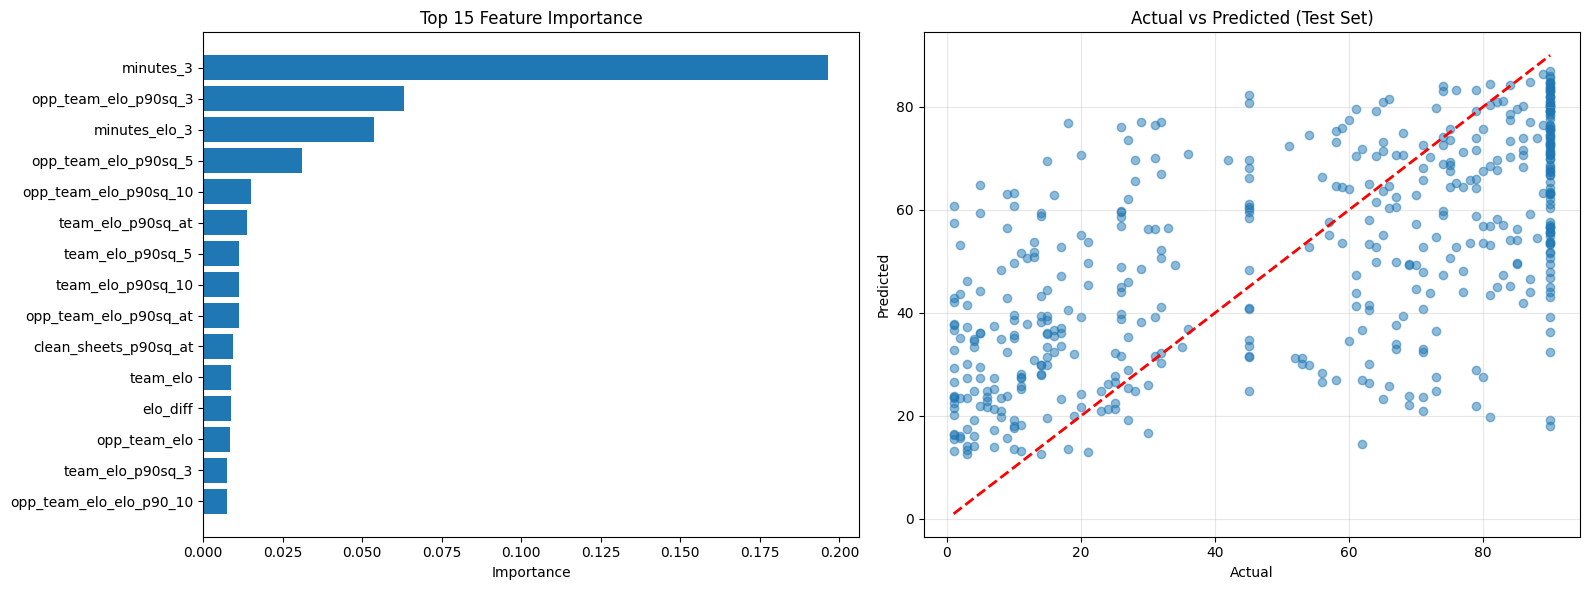

Cleaned df size: 8272/27834

Training Set Performance:
R² Score: 0.6712
RMSE: 18.3515
MAE: 15.1033

Test Set Performance:
R² Score: 0.3234
RMSE: 27.0085
MAE: 22.2358

Top 20 Feature Importances:
                feature  importance
              minutes_3    0.353587
   opp_team_elo_p90sq_3    0.029463
  opp_team_elo_p90sq_10    0.018934
   opp_team_elo_p90sq_5    0.016999
             minutes_10    0.013210
                 bps_10    0.011483
      minutes_elo_p90_5    0.009872
          minutes_elo_3    0.009861
         minutes_elo_10    0.009132
                  bps_3    0.008260
           opp_team_elo    0.008198
        xg_over_g_ratio    0.008110
  clean_sheets_p90sq_at    0.007112
  opp_team_elo_p90sq_at    0.006745
         opp_team_elo_3    0.006302
         opp_team_elo_5    0.006243
goals_conceded_p90sq_at    0.006148
        opp_team_elo_10    0.005962
  goals_conceded_elo_10    0.005932
               elo_diff    0.005749


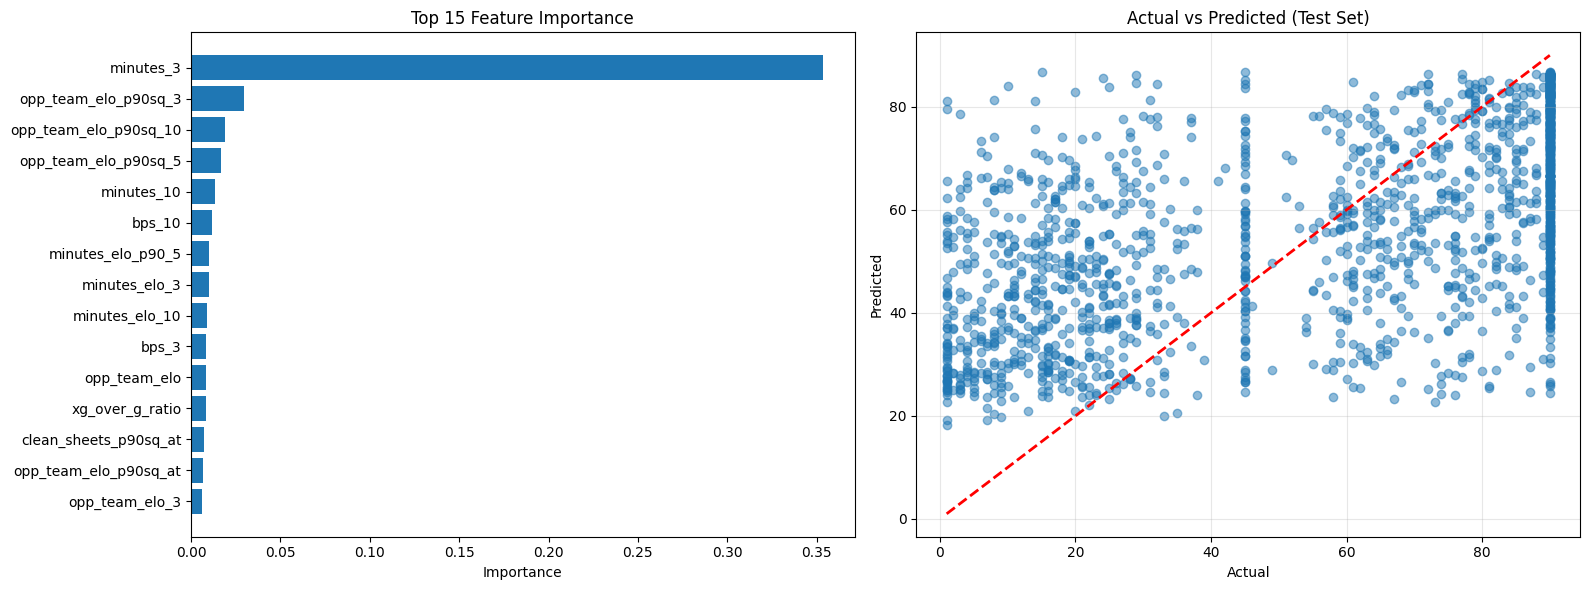

Cleaned df size: 5149/20045

Training Set Performance:
R² Score: 0.6854
RMSE: 16.4396
MAE: 12.2780

Test Set Performance:
R² Score: 0.2279
RMSE: 25.8926
MAE: 19.0511

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.132314
        team_elo_p90sq_3    0.055637
    opp_team_elo_p90sq_3    0.046464
   opp_team_elo_p90sq_10    0.025675
opp_team_elo_elo_p90sq_3    0.020658
    opp_team_elo_p90sq_5    0.013473
         xg_over_g_ratio    0.012687
         opp_team_elo_10    0.011271
           minutes_elo_3    0.011029
       xassists_p90sq_at    0.011002
          opp_team_elo_3    0.010873
            opp_team_elo    0.009755
 goals_conceded_p90sq_at    0.009536
          bonus_p90sq_at    0.009172
       team_elo_p90sq_10    0.008790
            bps_p90sq_at    0.008437
                elo_diff    0.008396
xgoals_conceded_p90sq_at    0.008089
   opp_team_elo_p90sq_at    0.008031
          opp_team_elo_5    0.007968


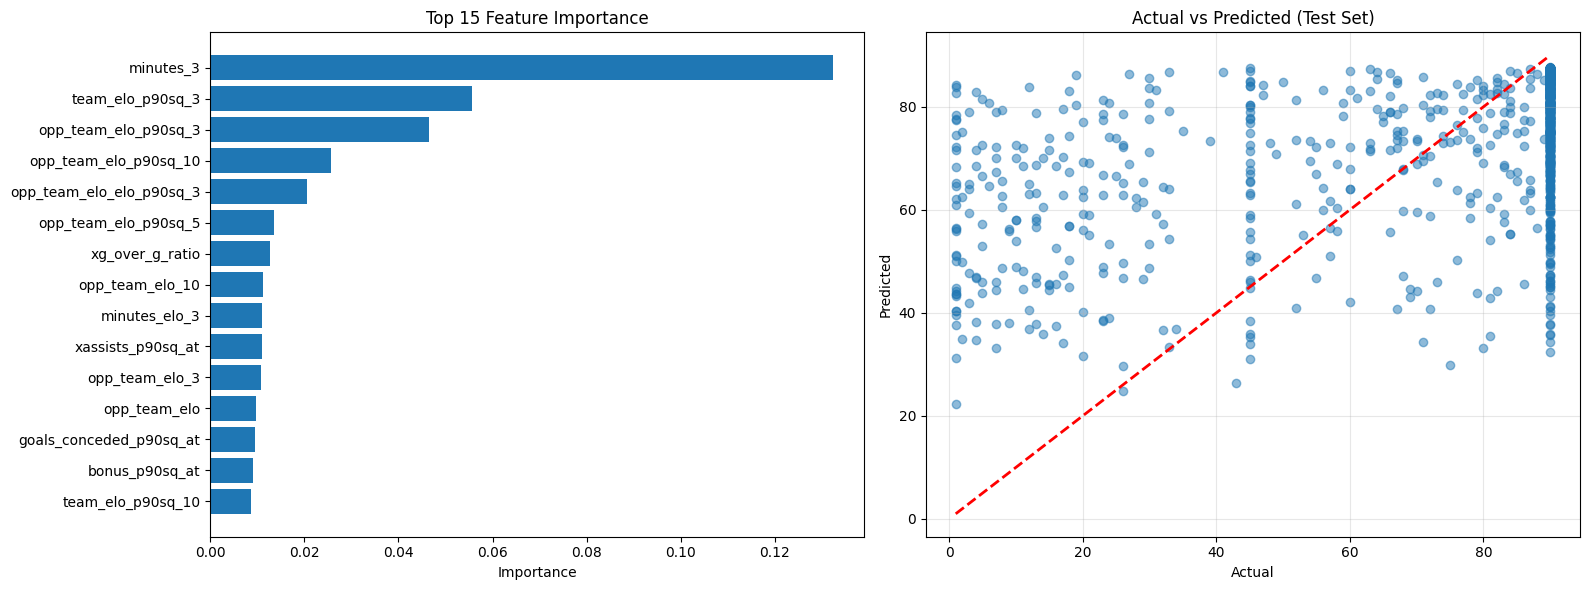

Cleaned df size: 3879/4142

Training Set Performance:
R² Score: 0.7011
RMSE: 2.8285
MAE: 0.5841

Test Set Performance:
R² Score: -0.1206
RMSE: 5.3508
MAE: 1.2120

Top 20 Feature Importances:
                    feature  importance
      opp_team_elo_p90sq_at    0.058240
                bps_p90sq_3    0.043725
               opp_team_elo    0.035273
                     bps_10    0.027688
               bps_p90sq_at    0.025866
                bps_p90sq_5    0.025707
          saves_elo_p90sq_3    0.023374
              minutes_elo_3    0.021944
             opp_team_elo_3    0.016421
             opp_team_elo_5    0.015940
            opp_team_elo_10    0.015330
          team_elo_p90sq_at    0.014958
                   elo_diff    0.014784
             team_elo_elo_3    0.014783
       team_elo_elo_p90sq_3    0.013956
goals_conceded_elo_p90sq_10    0.013746
      total_points_p90sq_10    0.012801
          saves_elo_p90sq_5    0.012612
    goals_conceded_p90sq_at    0.012565
         

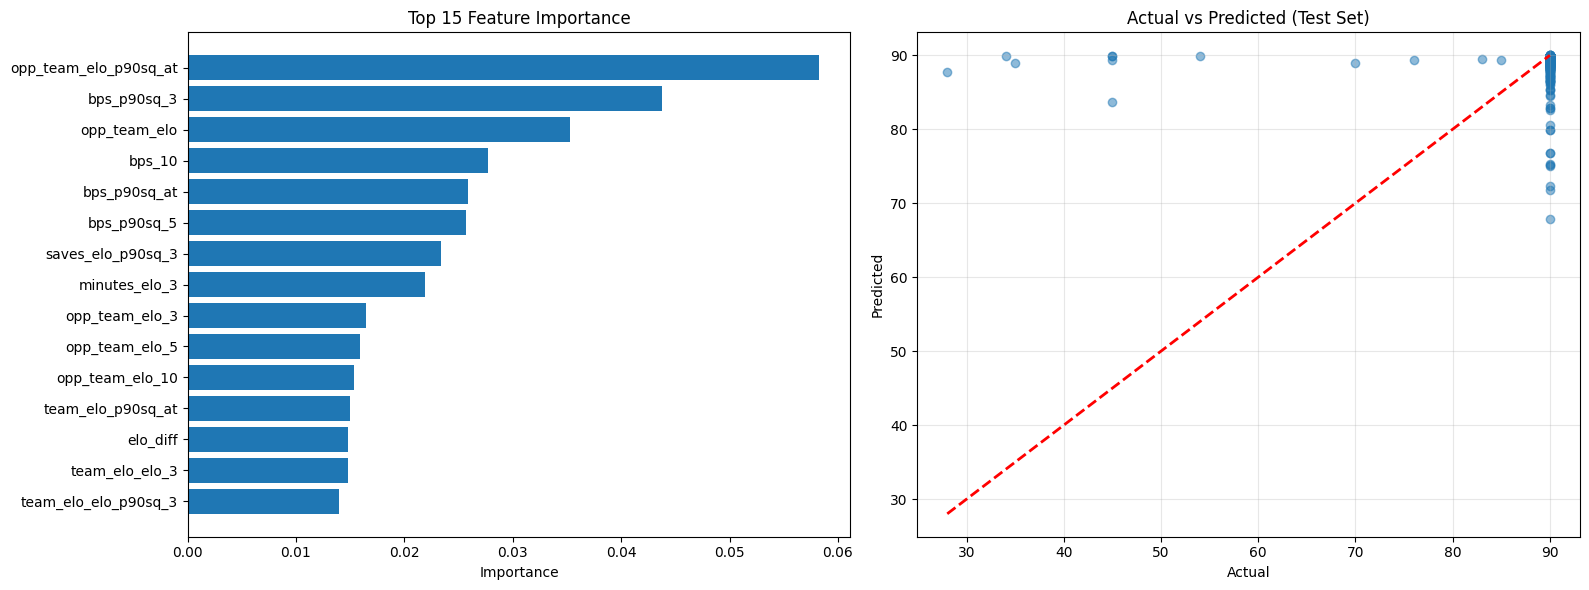

In [12]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2554/4278

Training Set Performance:
R² Score: 0.6350
RMSE: 0.2360
MAE: 0.1898

Test Set Performance:
R² Score: 0.0148
RMSE: 0.3841
MAE: 0.2916

Top 20 Feature Importances:
                feature  importance
  goals_scored_p90sq_at    0.036333
               elo_diff    0.024142
        xg_over_g_ratio    0.021522
               team_elo    0.019970
           opp_team_elo    0.019700
        opp_team_elo_10    0.017201
         opp_team_elo_3    0.016056
         opp_team_elo_5    0.016048
         bonus_p90sq_at    0.015821
    goals_scored_elo_10    0.015379
   opp_team_elo_p90sq_3    0.012834
       team_elo_p90sq_5    0.012564
goals_conceded_p90sq_at    0.012303
   opp_team_elo_p90sq_5    0.012152
  opp_team_elo_p90sq_10    0.011738
      team_elo_p90sq_at    0.011035
  total_points_p90sq_10    0.010935
  clean_sheets_p90sq_at    0.010912
       team_elo_p90sq_3    0.010831
           bps_p90sq_at    0.010702


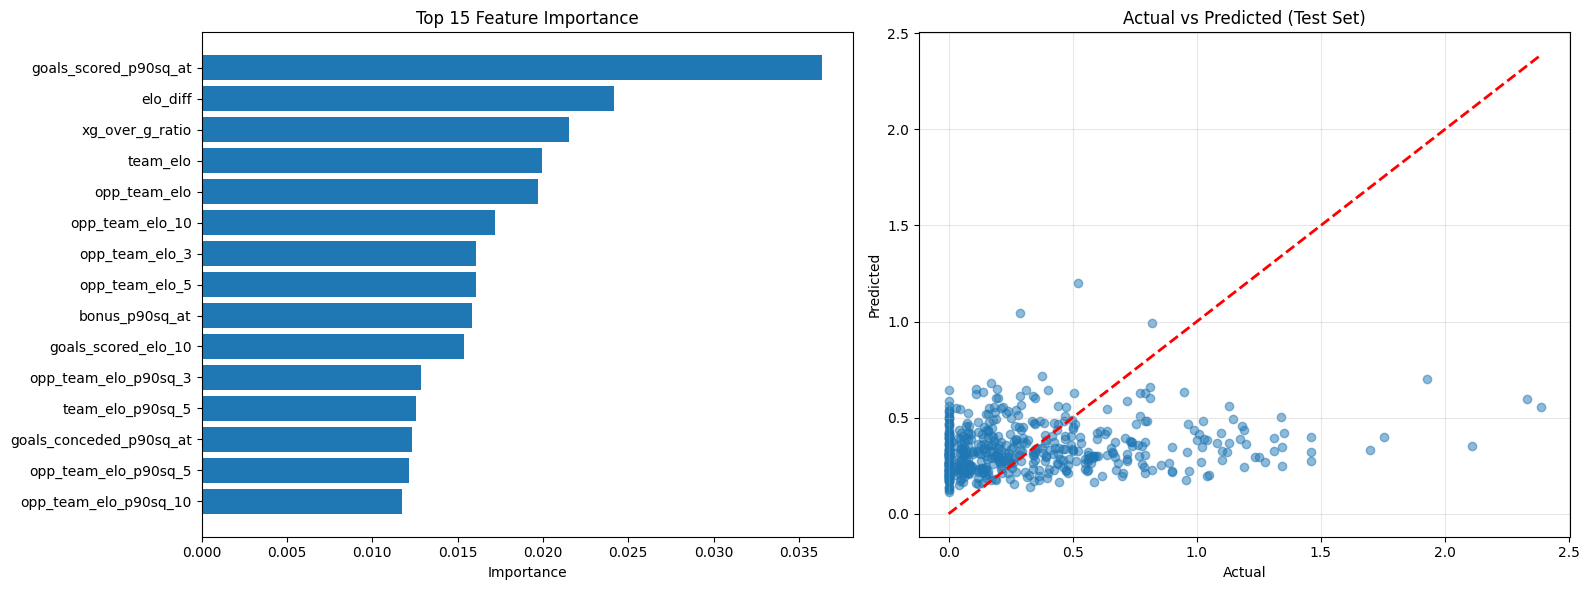

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 11881/18296

Training Set Performance:
R² Score: 0.3938
RMSE: 0.1743
MAE: 0.1184

Test Set Performance:
R² Score: 0.0657
RMSE: 0.2061
MAE: 0.1351

Top 20 Feature Importances:
                feature  importance
  goals_scored_p90sq_at    0.152136
           opp_team_elo    0.045983
         bonus_p90sq_at    0.028741
    goals_scored_elo_10    0.016869
               elo_diff    0.016232
        opp_team_elo_10    0.016213
         opp_team_elo_3    0.014856
       bps_elo_p90sq_10    0.014327
           bps_p90sq_at    0.013855
         opp_team_elo_5    0.013578
  clean_sheets_p90sq_at    0.012313
    total_points_elo_10    0.011524
      team_elo_p90sq_at    0.011326
  opp_team_elo_p90sq_10    0.010818
goals_conceded_p90sq_at    0.009146
           bps_p90sq_10    0.009068
  opp_team_elo_p90sq_at    0.008816
  total_points_p90sq_at    0.008645
  goals_conceded_elo_10    0.008560
   opp_team_elo_p90sq_3    0.008485


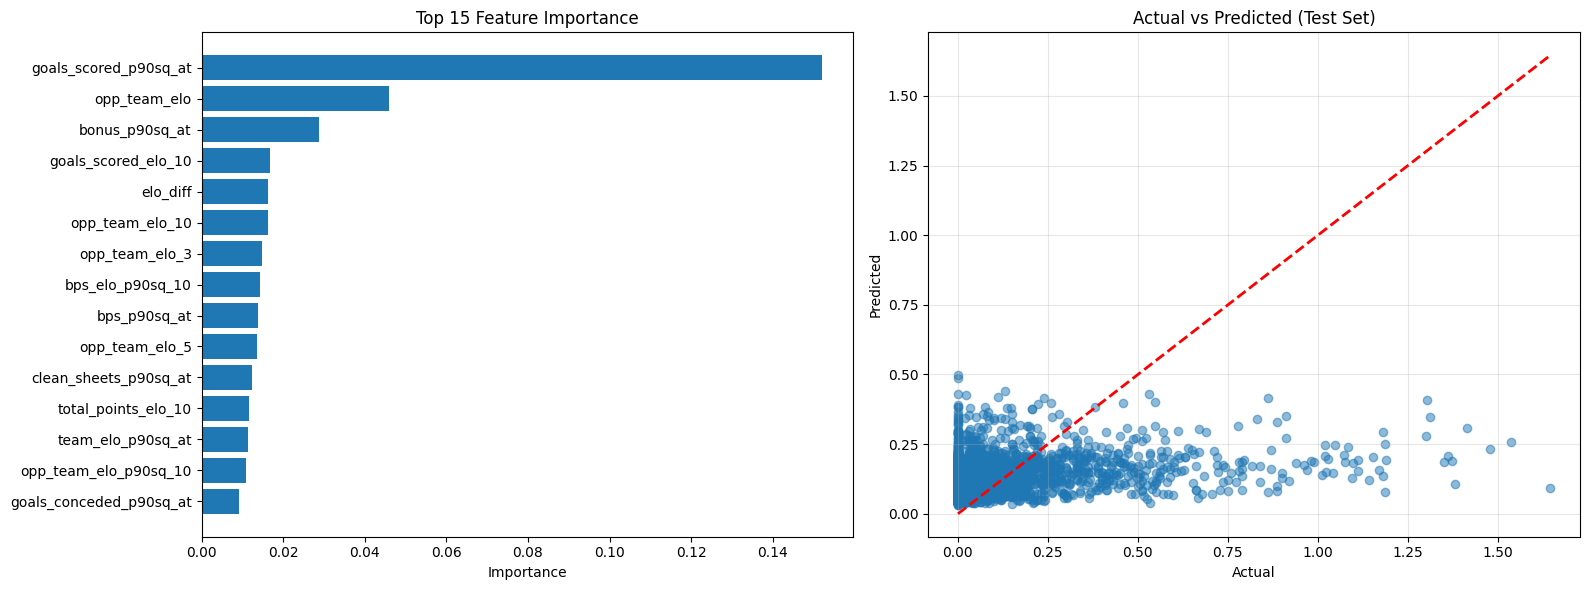

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 10176/16372

Training Set Performance:
R² Score: 0.2713
RMSE: 0.0920
MAE: 0.0555

Test Set Performance:
R² Score: -0.0226
RMSE: 0.1022
MAE: 0.0602

Top 20 Feature Importances:
                  feature  importance
             opp_team_elo    0.036805
           opp_team_elo_3    0.036248
    goals_scored_p90sq_at    0.032620
    goals_conceded_elo_10    0.023973
        team_elo_p90sq_at    0.023354
      goals_scored_elo_10    0.019427
          opp_team_elo_10    0.017537
    total_points_p90sq_at    0.017526
  goals_conceded_p90sq_at    0.017115
       total_points_elo_5    0.016793
goals_conceded_elo_p90_10    0.016090
   opp_team_elo_elo_p90_5    0.015935
            minutes_elo_5    0.015744
           opp_team_elo_5    0.015452
                 elo_diff    0.014039
    opp_team_elo_p90sq_10    0.013282
             bps_p90sq_at    0.012964
       total_points_p90_3    0.011686
       total_points_p90_5    0.011617
 

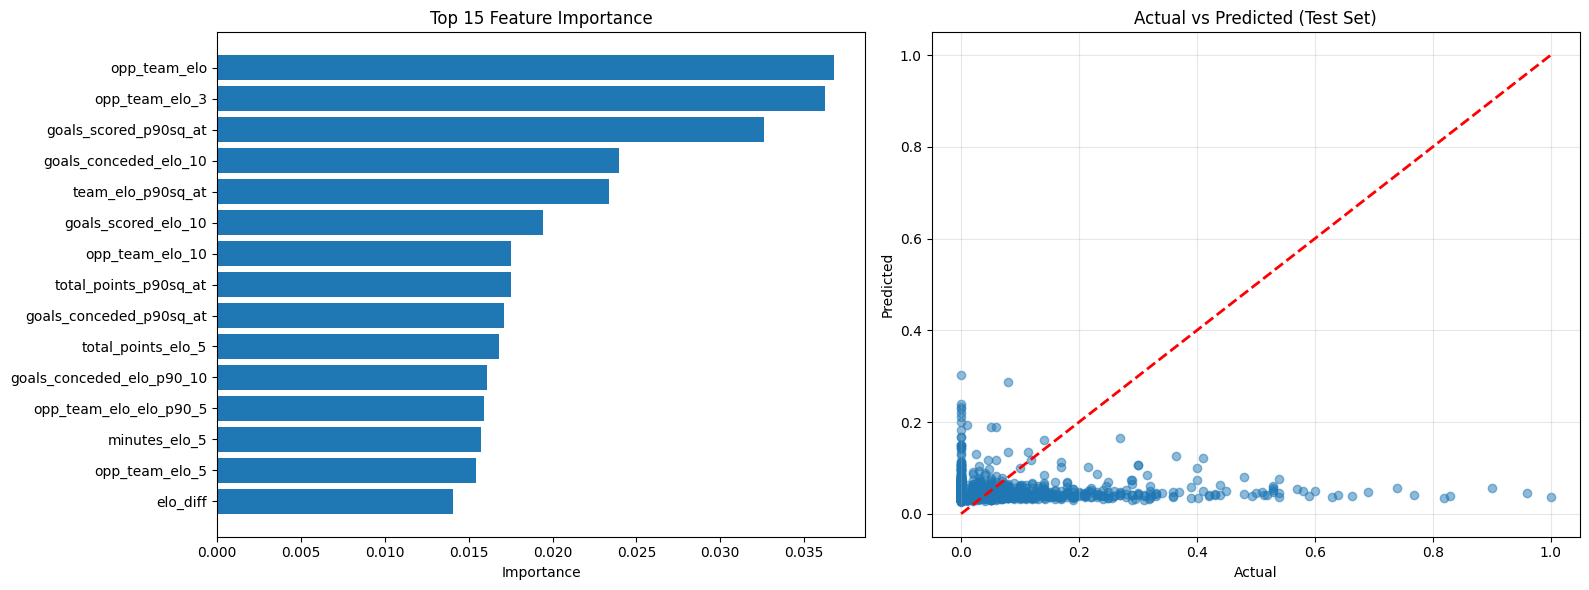

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 2746/4560

Training Set Performance:
R² Score: 0.5342
RMSE: 0.0798
MAE: 0.0540

Test Set Performance:
R² Score: 0.0044
RMSE: 0.1309
MAE: 0.0786

Top 20 Feature Importances:
                 feature  importance
            opp_team_elo    0.038645
                elo_diff    0.029413
           bps_elo_p90_5    0.023365
          opp_team_elo_3    0.023137
       minutes_elo_p90_5    0.021503
total_points_elo_p90sq_3    0.017363
    total_points_p90sq_3    0.016505
              bps_elo_10    0.015372
       minutes_elo_p90_3    0.014961
 opp_team_elo_elo_p90_10    0.014112
          opp_team_elo_5    0.013499
         xg_over_g_ratio    0.012871
             bonus_elo_5    0.012023
  opp_team_elo_elo_p90_3    0.011974
goals_scored_elo_p90sq_5    0.011787
    opp_team_elo_p90sq_5    0.011608
            bps_p90sq_at    0.011549
         opp_team_elo_10    0.011084
 goals_conceded_p90sq_at    0.010682
           minutes_elo

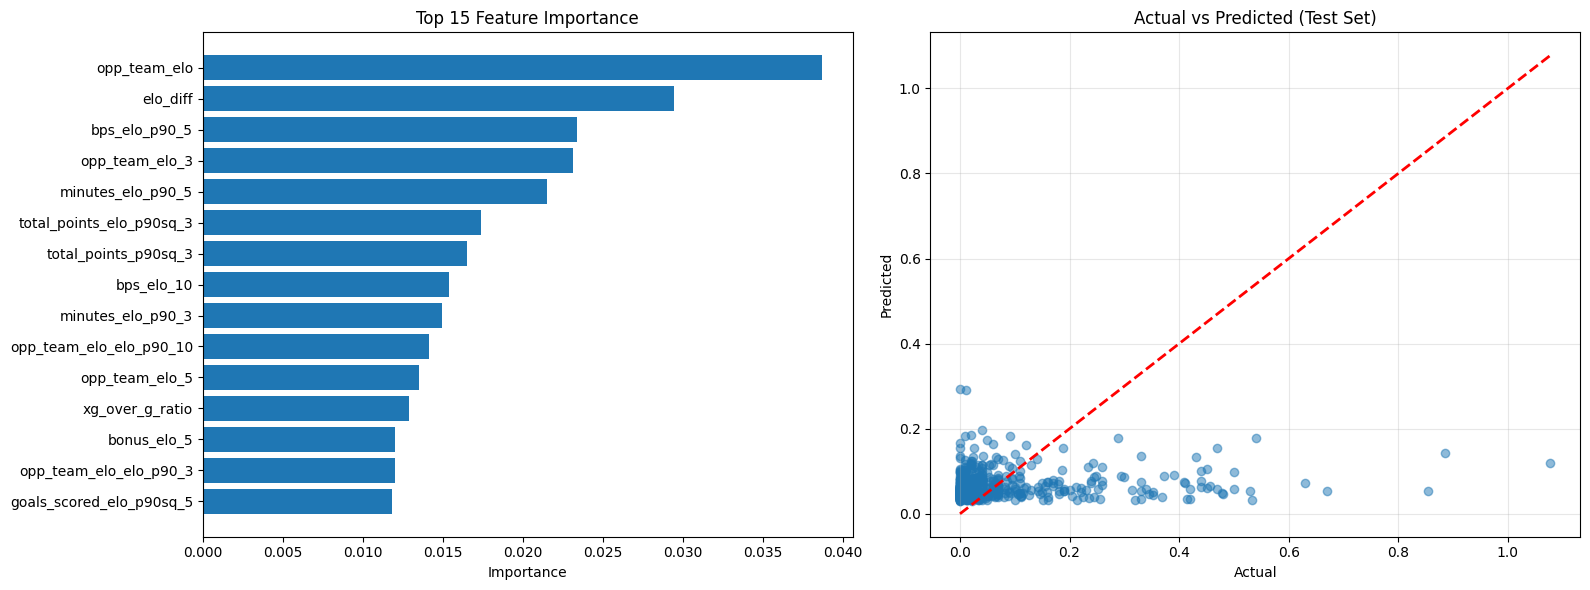

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 12302/18921

Training Set Performance:
R² Score: 0.4170
RMSE: 0.1241
MAE: 0.0881

Test Set Performance:
R² Score: 0.0835
RMSE: 0.1578
MAE: 0.1069

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.093767
         bonus_p90sq_at    0.067025
             bps_elo_10    0.032282
           opp_team_elo    0.026566
    total_points_elo_10    0.025657
  goals_scored_p90sq_at    0.021707
        opp_team_elo_10    0.017582
  total_points_p90sq_at    0.015394
                 bps_10    0.015241
         opp_team_elo_5    0.014534
           bps_p90sq_at    0.012968
         opp_team_elo_3    0.012798
  clean_sheets_p90sq_at    0.012683
               team_elo    0.010517
  opp_team_elo_p90sq_at    0.009826
           bps_p90sq_10    0.009505
             bps_p90_10    0.009322
      team_elo_p90sq_at    0.009061
goals_conceded_p90sq_at    0.008834
        total_points_10    0.008714


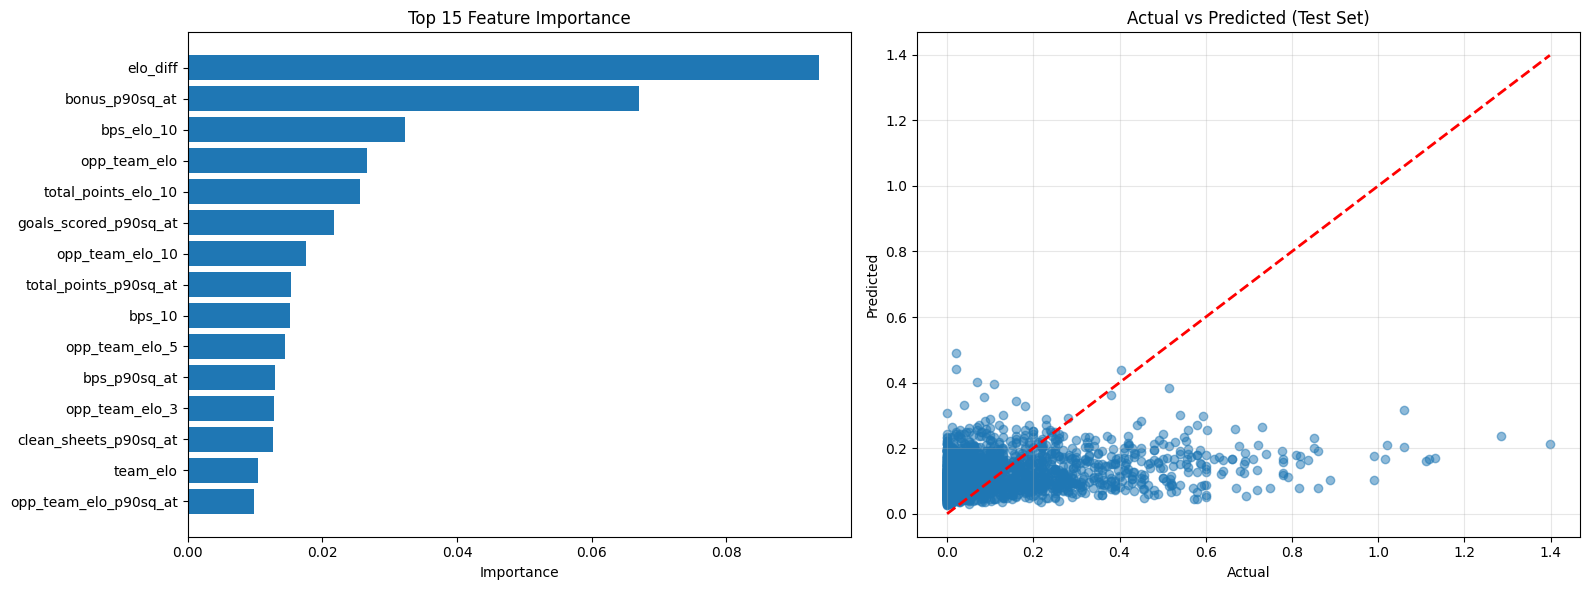

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 10372/16692

Training Set Performance:
R² Score: 0.3756
RMSE: 0.0832
MAE: 0.0512

Test Set Performance:
R² Score: 0.0563
RMSE: 0.0994
MAE: 0.0582

Top 20 Feature Importances:
                feature  importance
         bonus_p90sq_at    0.103261
               elo_diff    0.038014
           opp_team_elo    0.029944
goals_conceded_p90sq_at    0.028497
    minutes_elo_p90sq_3    0.023541
         opp_team_elo_3    0.019985
        opp_team_elo_10    0.018775
   goals_conceded_elo_3    0.017374
               team_elo    0.016779
  clean_sheets_p90sq_at    0.016640
                  bps_3    0.015385
    total_points_p90_10    0.013988
            bps_p90sq_5    0.013878
  opp_team_elo_p90sq_at    0.013496
  goals_scored_p90sq_at    0.013495
                 bps_10    0.012145
            bps_p90sq_3    0.012010
      team_elo_p90sq_at    0.011849
     team_elo_elo_p90_3    0.010996
           bps_p90sq_at    0.010801


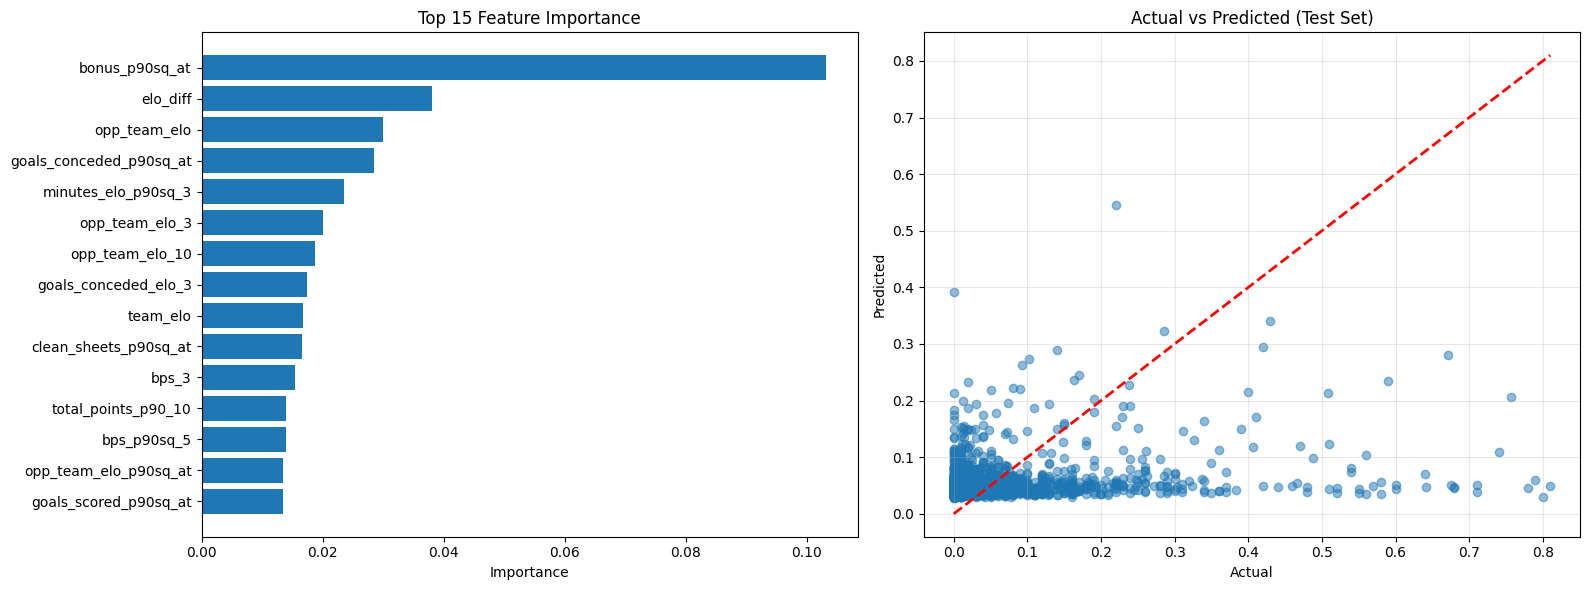

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 2746/4560

Training Set Performance:
R² Score: 0.6753
RMSE: 0.5292
MAE: 0.4293

Test Set Performance:
R² Score: 0.1346
RMSE: 0.8816
MAE: 0.6837

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.151041
               opp_team_elo    0.054702
            xg_over_g_ratio    0.041154
      clean_sheets_p90sq_at    0.025189
            opp_team_elo_10    0.021548
    goals_conceded_p90sq_at    0.014644
             opp_team_elo_3    0.012680
             opp_team_elo_5    0.012070
         minutes_elo_p90_10    0.011553
             bonus_p90sq_at    0.010481
          minutes_elo_p90_3    0.009417
                 minutes_10    0.009232
      goals_scored_p90sq_at    0.009023
      goals_conceded_elo_10    0.008441
goals_conceded_elo_p90sq_10    0.008419
         opp_team_elo_elo_5    0.008353
       goals_conceded_elo_5    0.008198
                team_elo_10    0.0

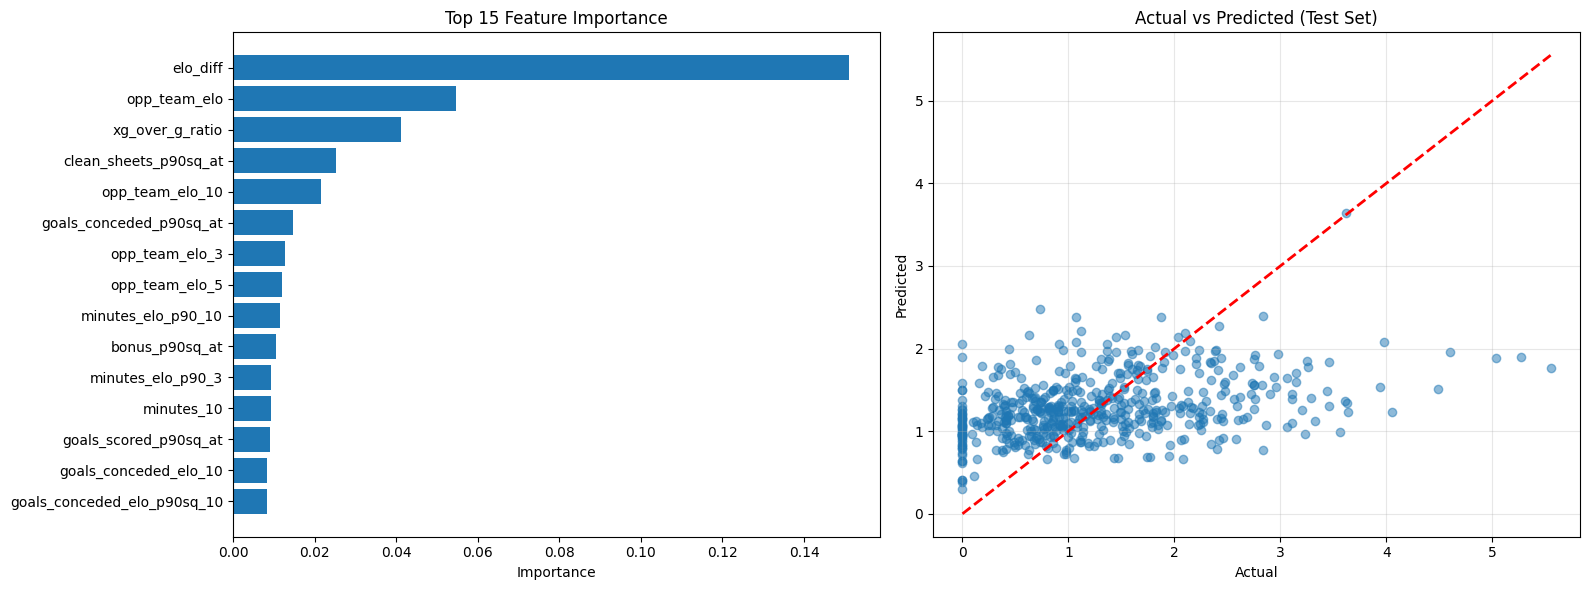

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 12302/18921

Training Set Performance:
R² Score: 0.5329
RMSE: 0.6387
MAE: 0.5084

Test Set Performance:
R² Score: 0.3119
RMSE: 0.7916
MAE: 0.6174

Top 20 Feature Importances:
              feature  importance
             elo_diff    0.253706
         opp_team_elo    0.071811
       opp_team_elo_5    0.034832
      opp_team_elo_10    0.032274
             team_elo    0.026138
       opp_team_elo_3    0.023354
          team_elo_10    0.021305
           team_elo_5    0.019776
           team_elo_3    0.016813
       team_elo_elo_3    0.015697
  minutes_elo_p90sq_3    0.014809
   opp_team_elo_elo_3    0.014792
   opp_team_elo_elo_5    0.014655
       team_elo_elo_5    0.014307
    minutes_elo_p90_3    0.014244
clean_sheets_p90sq_at    0.014109
  opp_team_elo_elo_10    0.013857
      team_elo_elo_10    0.010732
    minutes_elo_p90_5    0.010322
  minutes_elo_p90sq_5    0.010021


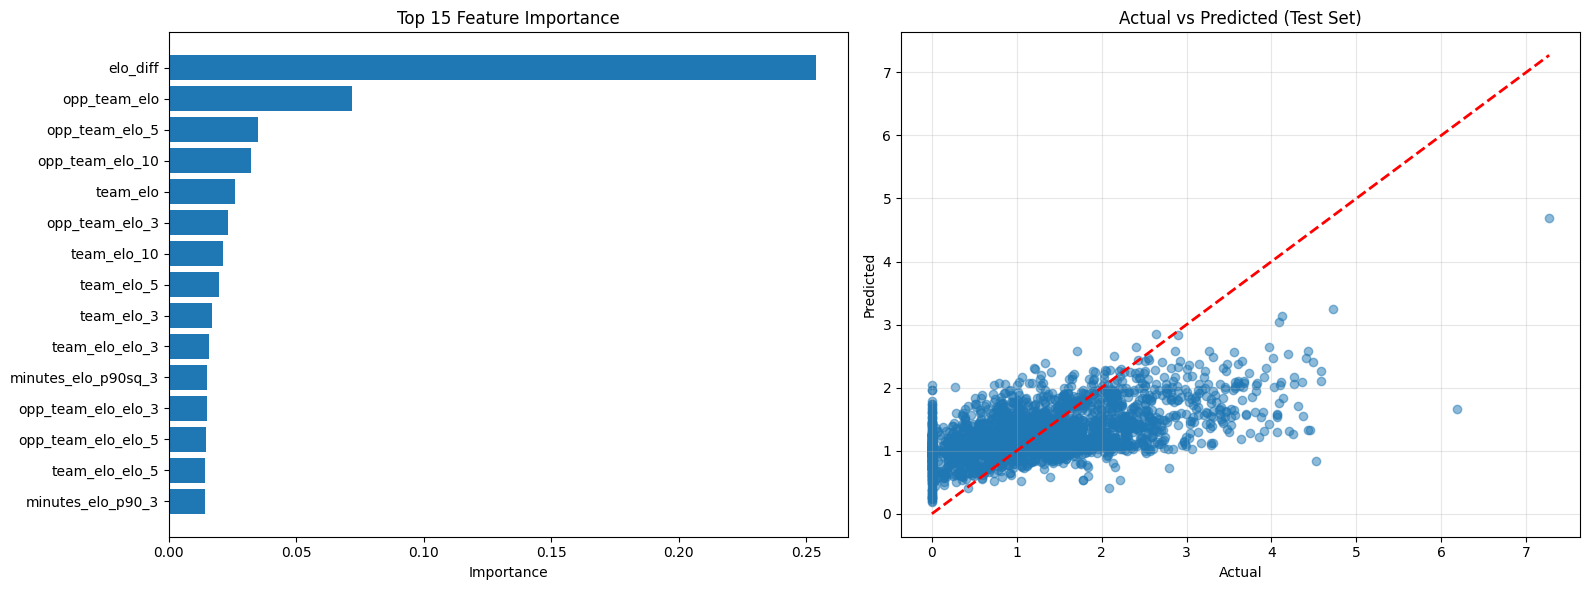

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 10372/16692

Training Set Performance:
R² Score: 0.5800
RMSE: 0.6127
MAE: 0.4879

Test Set Performance:
R² Score: 0.3207
RMSE: 0.7494
MAE: 0.5893

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.180767
           opp_team_elo    0.098199
         opp_team_elo_5    0.035963
    opp_team_elo_elo_10    0.029939
        opp_team_elo_10    0.026600
         opp_team_elo_3    0.021588
               team_elo    0.021134
  clean_sheets_p90sq_at    0.020108
            team_elo_10    0.019278
     opp_team_elo_elo_3    0.018142
             team_elo_5    0.017768
         team_elo_elo_3    0.017462
     opp_team_elo_elo_5    0.015283
goals_conceded_p90sq_at    0.015110
             team_elo_3    0.014323
         team_elo_elo_5    0.013570
    minutes_elo_p90sq_3    0.011025
      minutes_elo_p90_3    0.009978
  opp_team_elo_p90sq_at    0.009921
        team_elo_elo_10    0.009

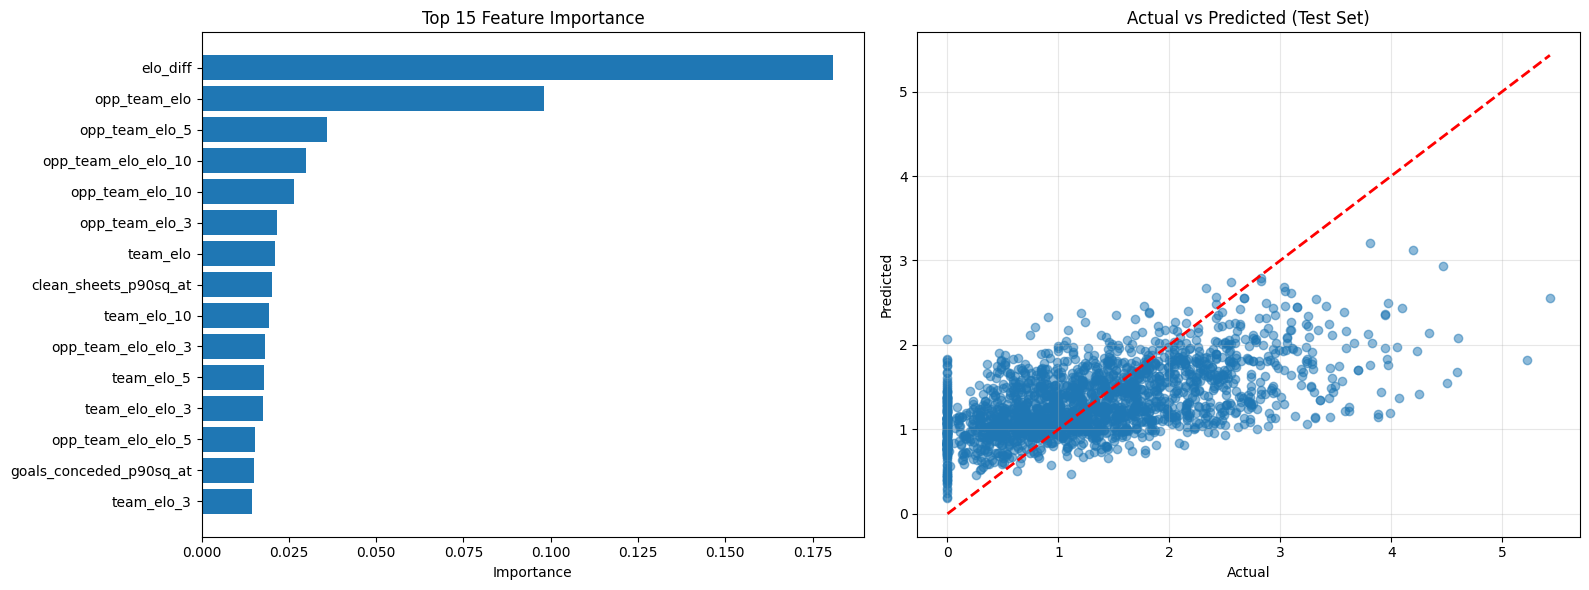

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 2544/4080

Training Set Performance:
R² Score: 0.6935
RMSE: 0.5143
MAE: 0.4184

Test Set Performance:
R² Score: 0.1531
RMSE: 0.8254
MAE: 0.6427

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.163593
           opp_team_elo    0.044556
         saves_p90sq_at    0.030616
  opp_team_elo_p90sq_at    0.025814
  opp_team_elo_p90sq_10    0.022196
goals_conceded_p90sq_at    0.021510
        opp_team_elo_10    0.019866
      team_elo_p90sq_at    0.019579
           bps_p90sq_at    0.015768
     saves_elo_p90sq_10    0.015047
  total_points_p90sq_at    0.012765
         opp_team_elo_5    0.012518
         saves_p90sq_10    0.011984
         bonus_p90sq_at    0.011025
          saves_p90sq_5    0.010895
   opp_team_elo_p90sq_5    0.010870
   opp_team_elo_p90sq_3    0.010869
           bps_p90sq_10    0.010787
      saves_elo_p90sq_5    0.010763
      saves_elo_p90sq_3    0.010438

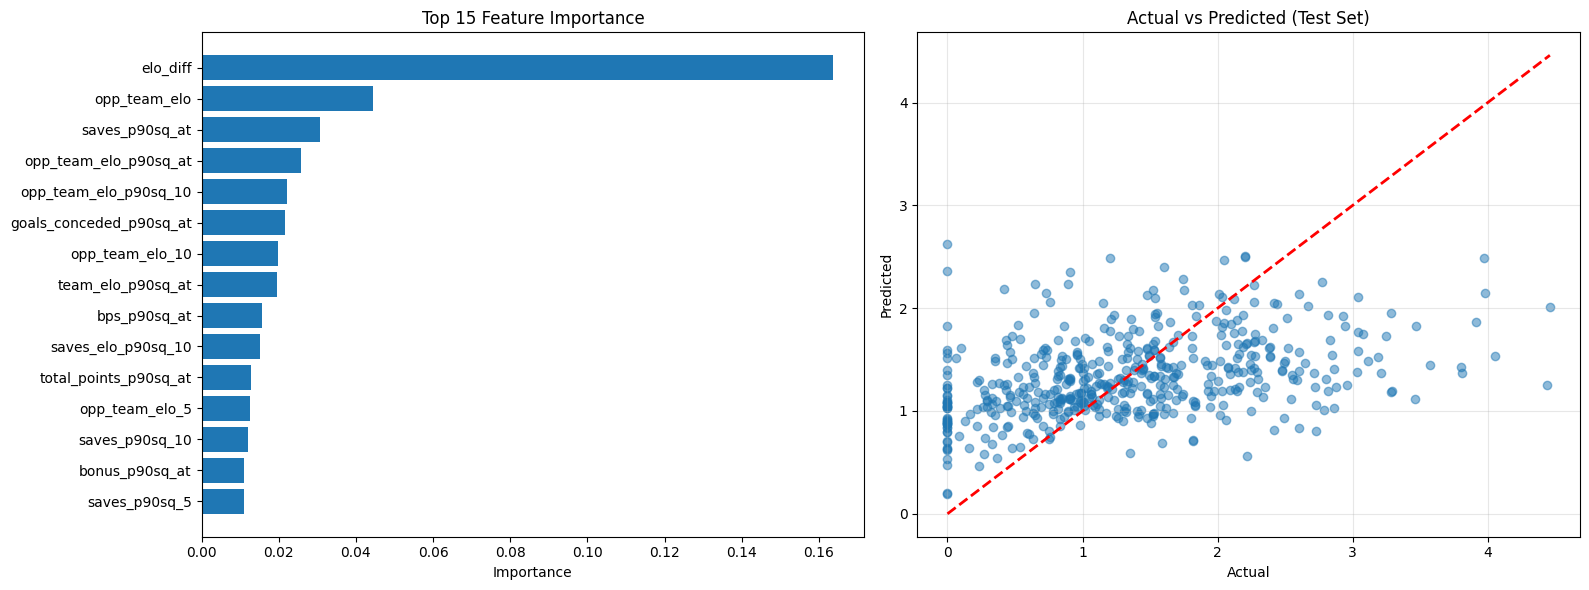

In [15]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4058/4560

Training Set Performance:
R² Score: 0.4799
RMSE: 13.3726
MAE: 10.8436

Test Set Performance:
R² Score: -0.0150
RMSE: 18.5245
MAE: 14.8260

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.069861
             opp_team_elo    0.030059
          opp_team_elo_10    0.025697
           opp_team_elo_5    0.016476
           opp_team_elo_3    0.014973
  goals_conceded_p90sq_at    0.014933
       opp_team_elo_elo_5    0.014742
      minutes_elo_p90sq_5    0.014321
               bps_elo_10    0.014021
    total_points_p90sq_at    0.014014
    clean_sheets_p90sq_at    0.013528
           bonus_p90sq_at    0.013514
clean_sheets_elo_p90sq_10    0.012992
    opp_team_elo_p90sq_at    0.011423
        minutes_elo_p90_3    0.010889
     goals_conceded_elo_5    0.010134
     minutes_elo_p90sq_10    0.010030
                bps_elo_3    0.009951
        minutes_elo_p90_5    0.009712
total_poi

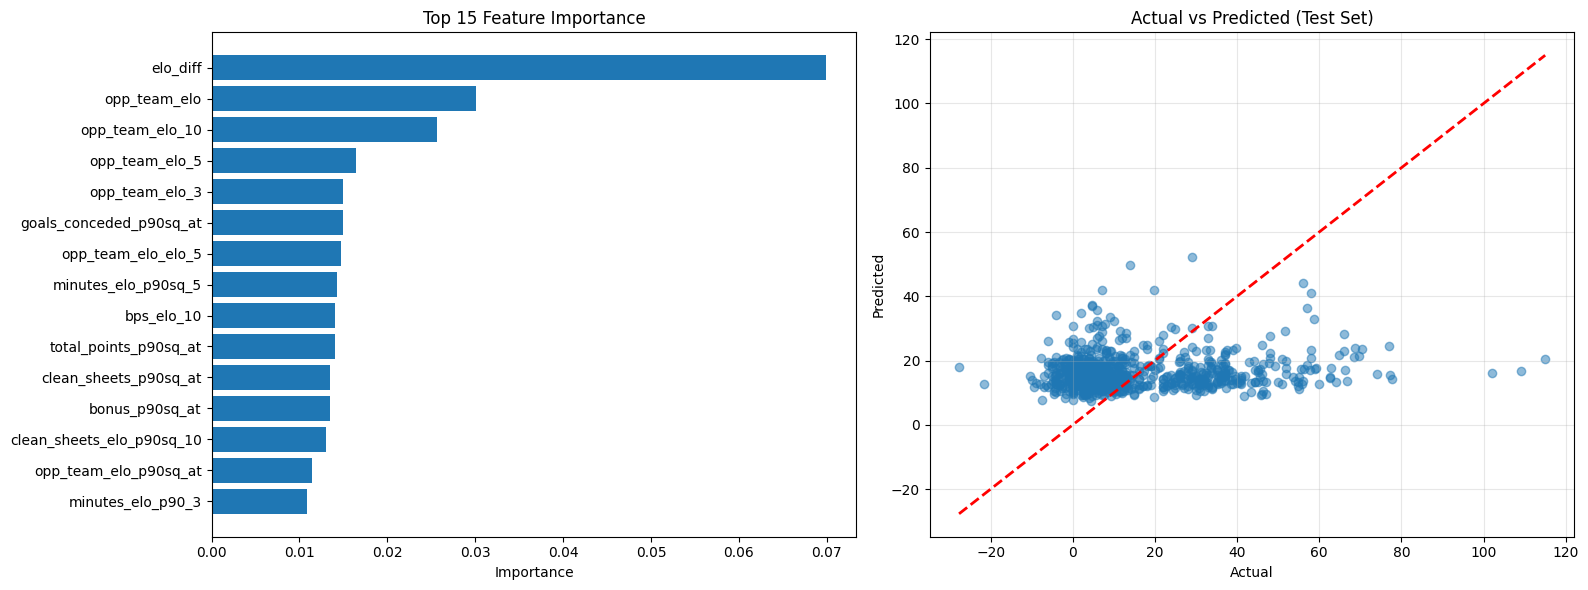

target=bps_per90, MID_bps_predictor
Cleaned df size: 18316/18921

Training Set Performance:
R² Score: 0.3164
RMSE: 9.5010
MAE: 7.1994

Test Set Performance:
R² Score: 0.0606
RMSE: 10.9901
MAE: 8.0419

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.130497
             bps_elo_10    0.035685
                 bps_10    0.024538
           opp_team_elo    0.020068
         bonus_p90sq_at    0.019435
        opp_team_elo_10    0.018384
         opp_team_elo_5    0.014727
                  bps_5    0.014520
         opp_team_elo_3    0.012746
  goals_scored_p90sq_at    0.011979
           bps_p90sq_at    0.010610
              bps_elo_5    0.010157
goals_conceded_p90sq_at    0.009861
              bps_elo_3    0.009834
              bps_p90_3    0.009540
    total_points_elo_10    0.008899
            bps_p90sq_5    0.008827
    clean_sheets_elo_10    0.008594
  clean_sheets_p90sq_at    0.008531
      team_elo_p90sq_at    0.008349


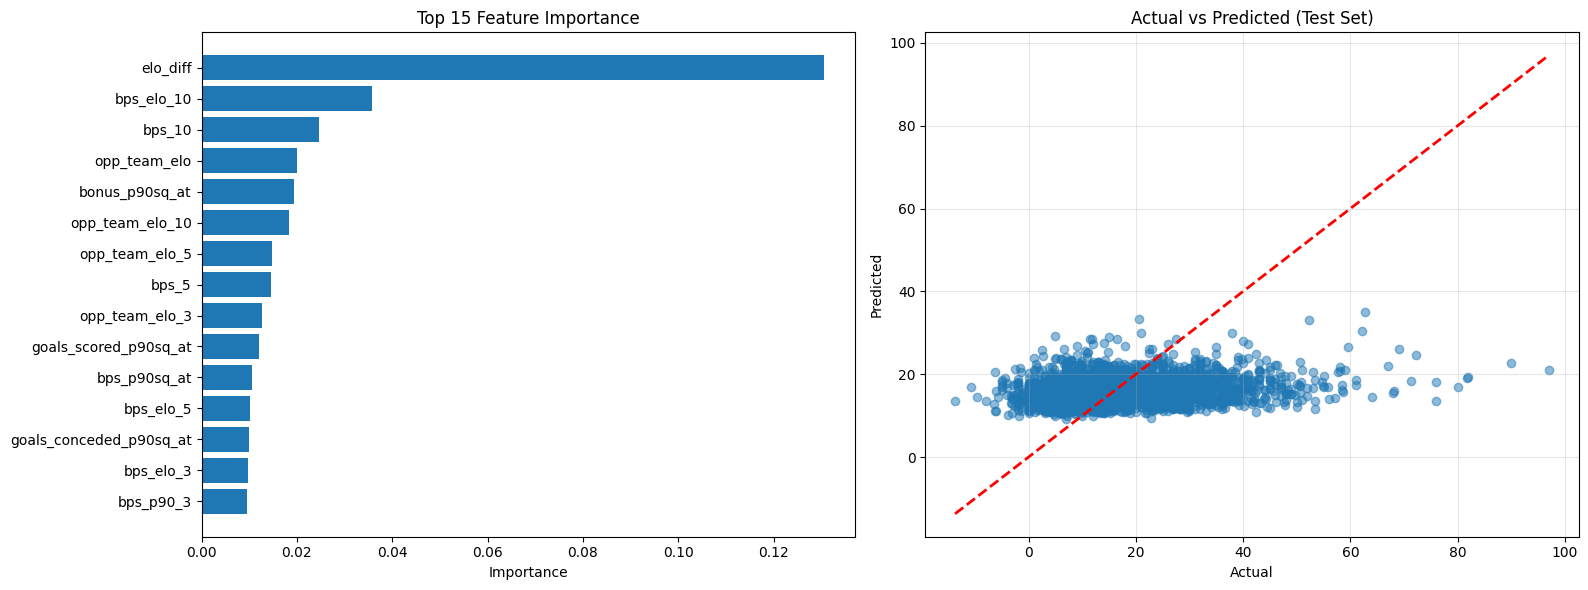

target=bps_per90, DEF_bps_predictor
Cleaned df size: 15699/16692

Training Set Performance:
R² Score: 0.4279
RMSE: 7.4816
MAE: 5.9869

Test Set Performance:
R² Score: 0.1510
RMSE: 9.0085
MAE: 7.0988

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.225649
           opp_team_elo    0.028412
        opp_team_elo_10    0.027443
         opp_team_elo_5    0.021996
         opp_team_elo_3    0.018031
         bonus_p90sq_at    0.016290
            team_elo_10    0.012598
               team_elo    0.012161
goals_conceded_p90sq_at    0.011698
  clean_sheets_p90sq_at    0.011492
            bps_p90sq_5    0.011019
             bps_p90_10    0.010965
           bps_p90sq_at    0.010109
             bps_elo_10    0.009386
  goals_scored_p90sq_at    0.009354
        bps_elo_p90sq_3    0.008693
       bps_elo_p90sq_10    0.008440
      minutes_elo_p90_3    0.008379
            bps_p90sq_3    0.008240
              bps_p90_5    0.008013


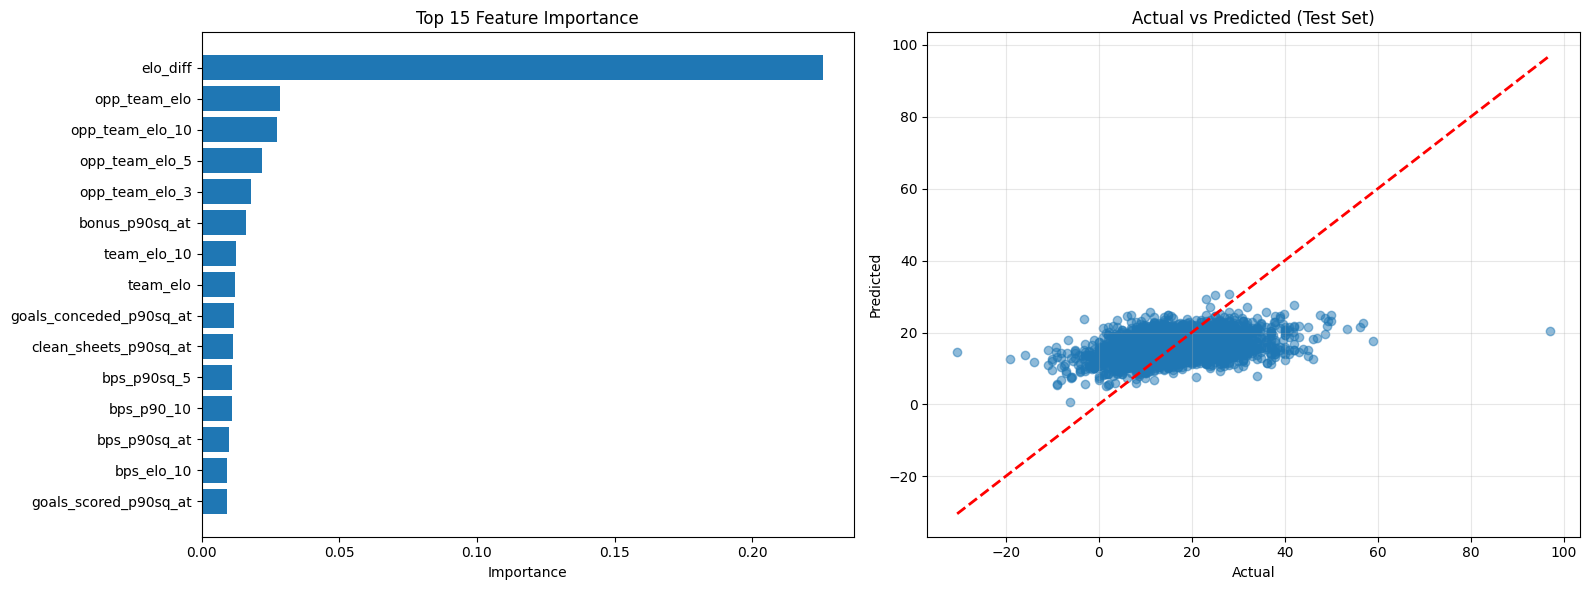

target=bps_per90, GK_bps_predictor
Cleaned df size: 3842/4080

Training Set Performance:
R² Score: 0.5539
RMSE: 5.9728
MAE: 4.8487

Test Set Performance:
R² Score: 0.0240
RMSE: 8.4897
MAE: 6.7939

Top 20 Feature Importances:
                    feature  importance
               bps_p90sq_10    0.038542
                 bps_p90_10    0.029013
            opp_team_elo_10    0.028331
               opp_team_elo    0.026661
               bps_p90sq_at    0.023725
                     bps_10    0.020280
             saves_p90sq_10    0.020082
      total_points_p90sq_10    0.019602
      opp_team_elo_p90sq_10    0.018726
                   elo_diff    0.017984
      opp_team_elo_p90sq_at    0.016899
                bps_p90sq_3    0.016473
          saves_elo_p90sq_3    0.016176
             saves_p90sq_at    0.015618
    goals_conceded_p90sq_at    0.015496
          saves_elo_p90sq_5    0.014795
         saves_elo_p90sq_10    0.014425
goals_conceded_elo_p90sq_10    0.014375
             op

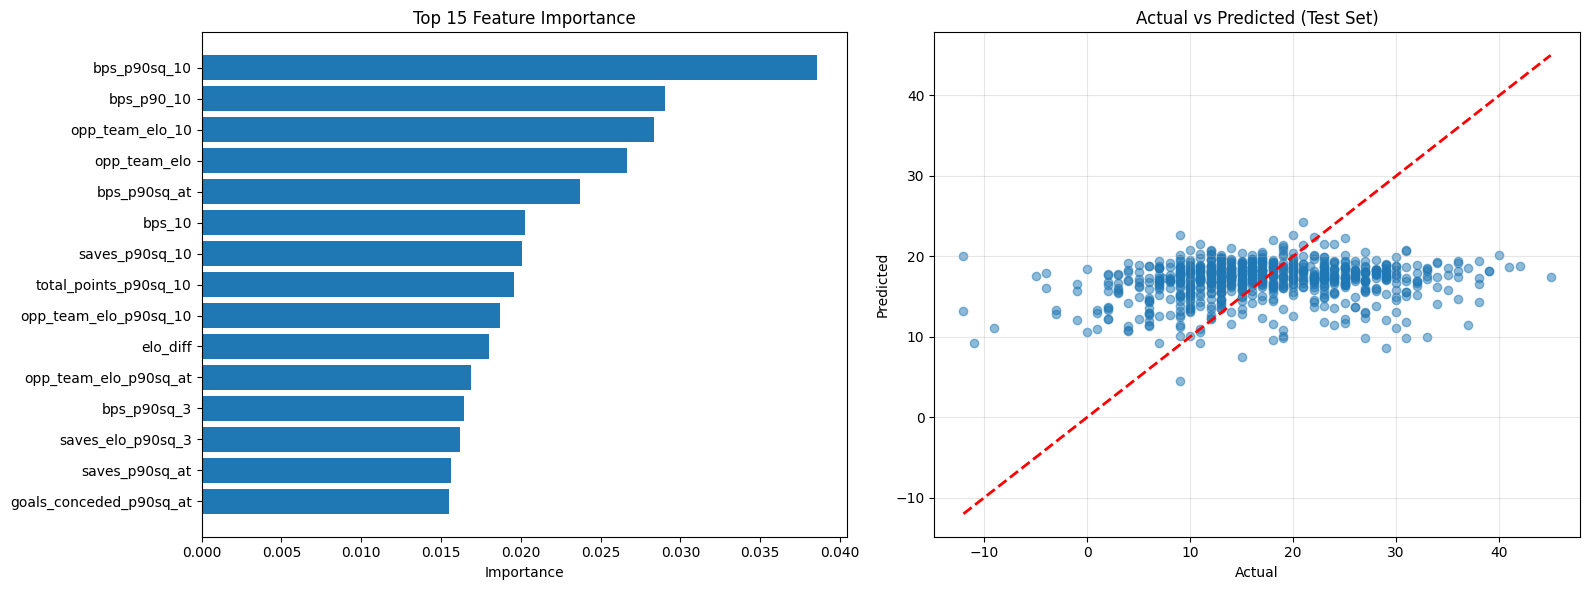

In [16]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 3842/4099

Training Set Performance:
R² Score: 0.5915
RMSE: 1.2598
MAE: 1.0217

Test Set Performance:
R² Score: 0.0404
RMSE: 1.8881
MAE: 1.4891

Top 20 Feature Importances:
                 feature  importance
                elo_diff    0.147363
            opp_team_elo    0.021458
          saves_p90sq_at    0.018053
          opp_team_elo_5    0.018050
         opp_team_elo_10    0.016126
 goals_conceded_p90sq_at    0.015138
            bps_p90sq_at    0.014768
          saves_p90sq_10    0.014677
   opp_team_elo_p90sq_at    0.013821
       team_elo_p90sq_at    0.013668
          opp_team_elo_3    0.012091
total_points_elo_p90sq_5    0.012050
       saves_elo_p90sq_5    0.011913
   opp_team_elo_p90sq_10    0.011790
         bps_elo_p90sq_5    0.011713
          bonus_p90sq_at    0.011569
   total_points_p90sq_at    0.011385
      saves_elo_p90sq_10    0.011224
    opp_team_elo_p90sq_3    0.010559
       saves_elo_p90sq_3    0.0

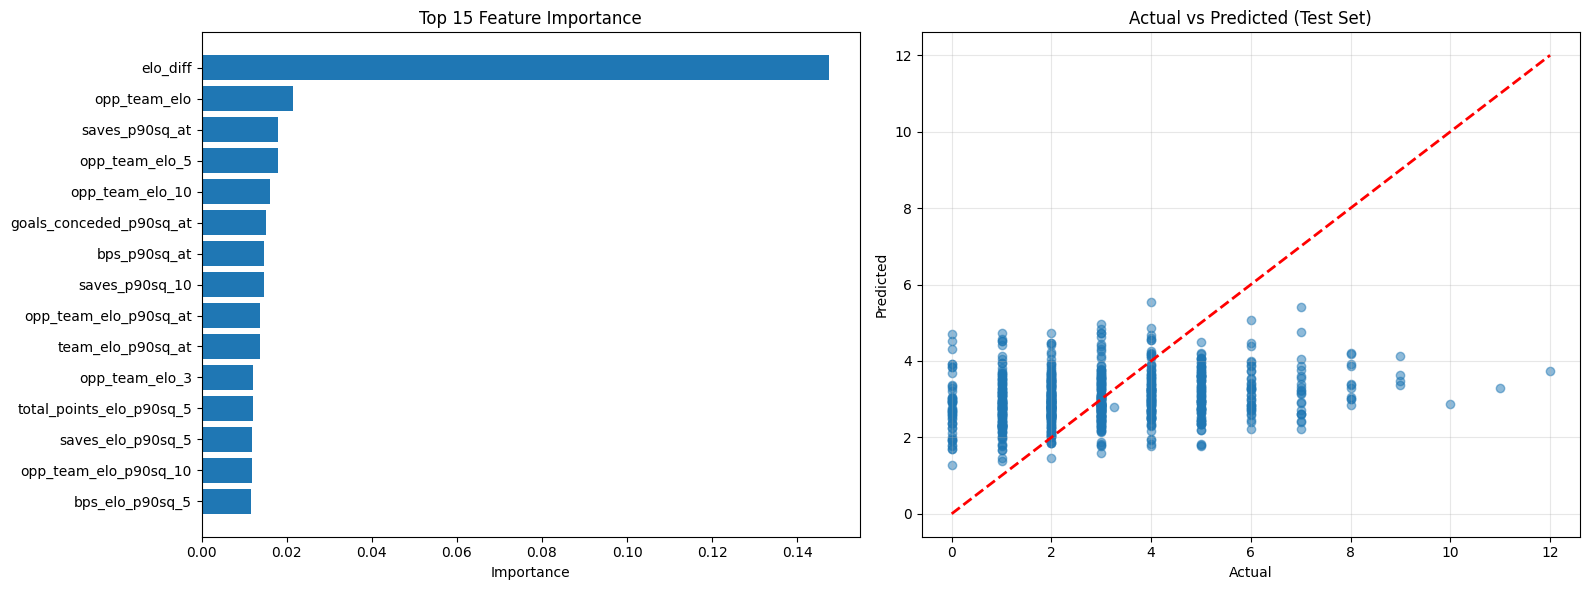

In [17]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 541/5040

Training Set Performance:
R² Score: 0.8063
RMSE: 1.2360
MAE: 0.9824

Test Set Performance:
R² Score: 0.0883
RMSE: 2.5223
MAE: 2.0116

Top 20 Feature Importances:
                feature  importance
  clean_sheets_p90sq_at    0.045688
   total_points_p90sq_3    0.029900
  goals_scored_p90sq_at    0.027392
         opp_team_elo_5    0.027245
  goals_conceded_p90_10    0.025326
        opp_team_elo_10    0.020300
  opp_team_elo_p90sq_at    0.018714
       team_elo_p90sq_5    0.017142
   opp_team_elo_p90sq_5    0.017103
           opp_team_elo    0.016721
goals_conceded_p90sq_at    0.016326
     minutes_elo_p90_10    0.015861
  total_points_p90sq_at    0.015083
         bonus_p90sq_at    0.015072
         opp_team_elo_3    0.014845
  goals_conceded_elo_10    0.013146
           bps_p90sq_at    0.012955
            bps_p90sq_5    0.012835
               team_elo    0.011792
    total_points_p90_10    0.0113

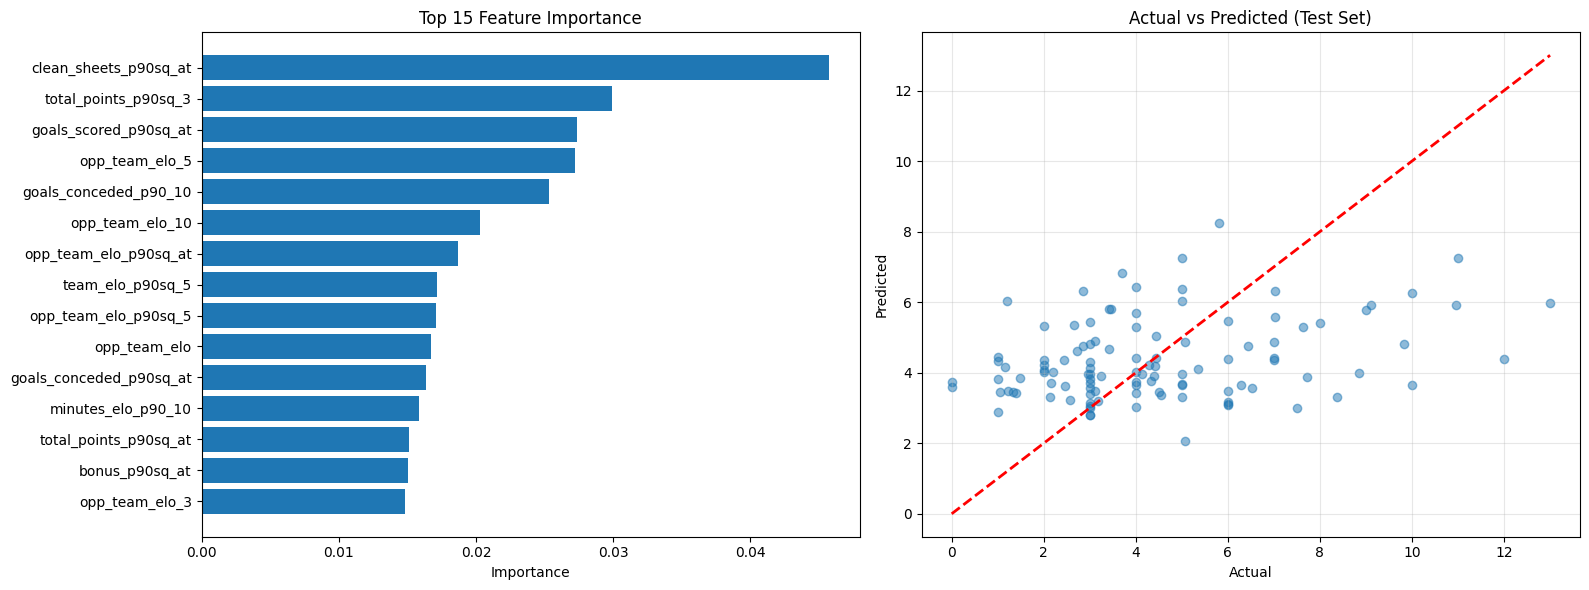

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 2554/20808

Training Set Performance:
R² Score: 0.7057
RMSE: 2.2882
MAE: 1.8400

Test Set Performance:
R² Score: 0.1209
RMSE: 3.9734
MAE: 3.1793

Top 20 Feature Importances:
                    feature  importance
      goals_scored_p90sq_at    0.093108
    goals_conceded_p90sq_at    0.036812
             bonus_p90sq_at    0.028541
      total_points_p90sq_at    0.022178
               bps_p90sq_at    0.019060
      goals_conceded_elo_10    0.018979
          team_elo_p90sq_at    0.017150
       opp_team_elo_p90sq_3    0.014438
                   elo_diff    0.014052
      clean_sheets_p90sq_at    0.013899
               opp_team_elo    0.013486
goals_conceded_elo_p90sq_10    0.012632
             opp_team_elo_3    0.011843
           team_elo_p90sq_3    0.011716
             opp_team_elo_5    0.011126
      opp_team_elo_p90sq_at    0.010917
            opp_team_elo_10    0.010783
                      bps_3    

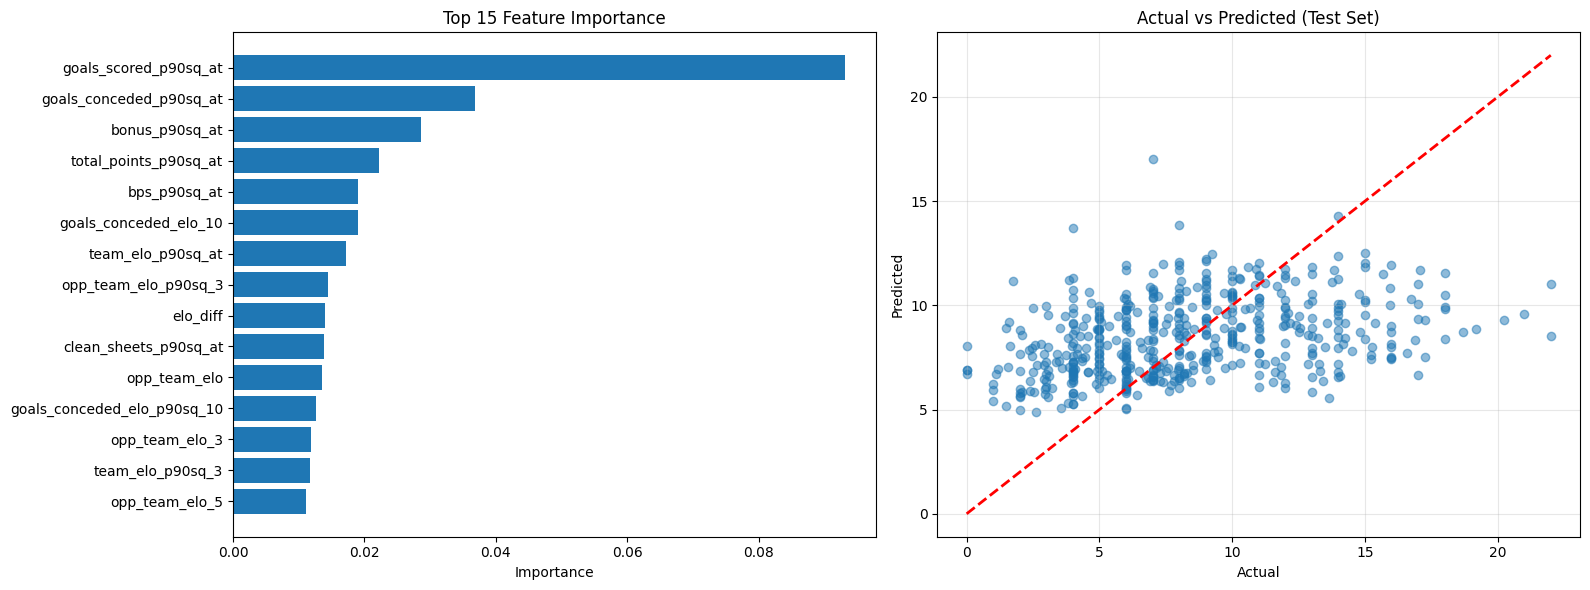

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 2141/17637

Training Set Performance:
R² Score: 0.6631
RMSE: 2.2492
MAE: 1.8278

Test Set Performance:
R² Score: 0.0418
RMSE: 3.7210
MAE: 3.0229

Top 20 Feature Importances:
                feature  importance
  opp_team_elo_p90sq_at    0.035831
goals_conceded_p90sq_at    0.023895
  total_points_p90sq_at    0.018652
  opp_team_elo_p90sq_10    0.018100
      team_elo_p90sq_at    0.017724
           opp_team_elo    0.017680
        opp_team_elo_10    0.016483
   opp_team_elo_p90sq_5    0.016192
         opp_team_elo_3    0.014565
  goals_scored_p90sq_at    0.013926
   opp_team_elo_p90sq_3    0.013615
         bonus_p90sq_at    0.013481
               elo_diff    0.012879
            bps_p90sq_3    0.012842
        bps_elo_p90sq_3    0.012796
           bps_p90sq_at    0.012781
            team_elo_10    0.012182
         opp_team_elo_5    0.012035
  goals_conceded_elo_10    0.012029
  total_points_p90sq_10    0.01

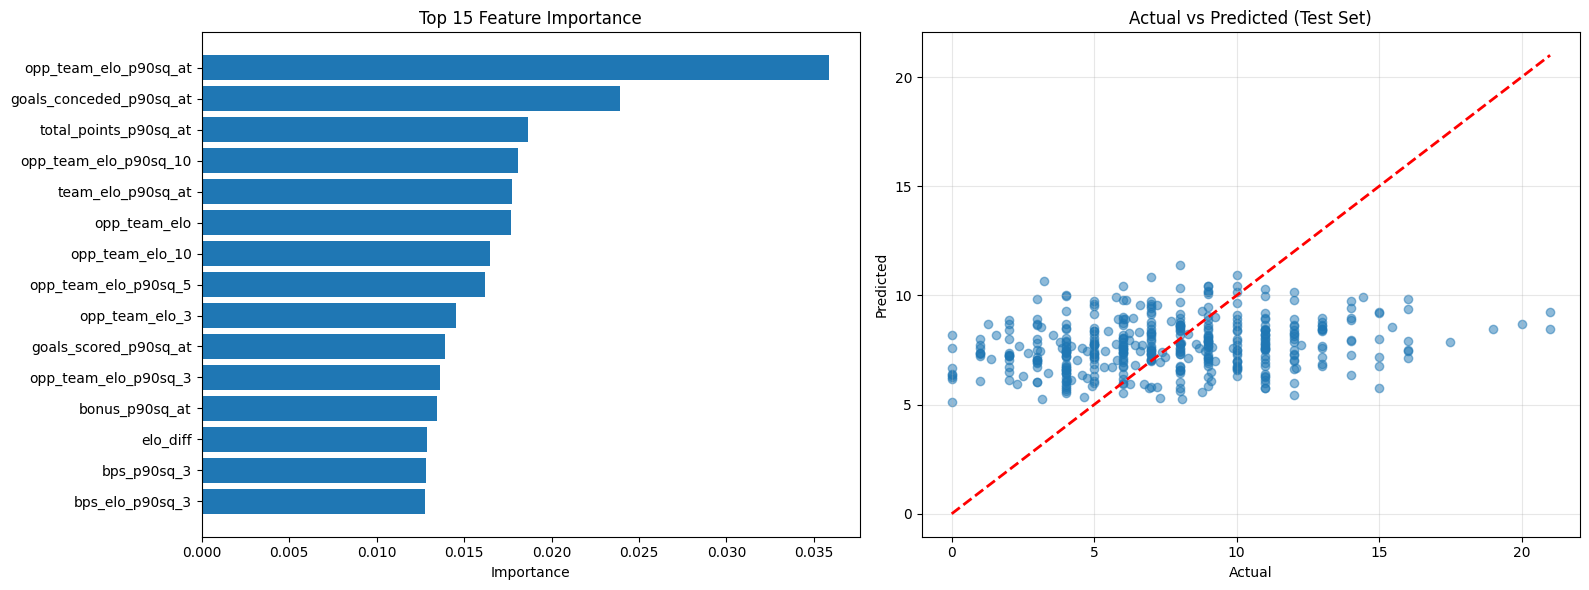

In [18]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

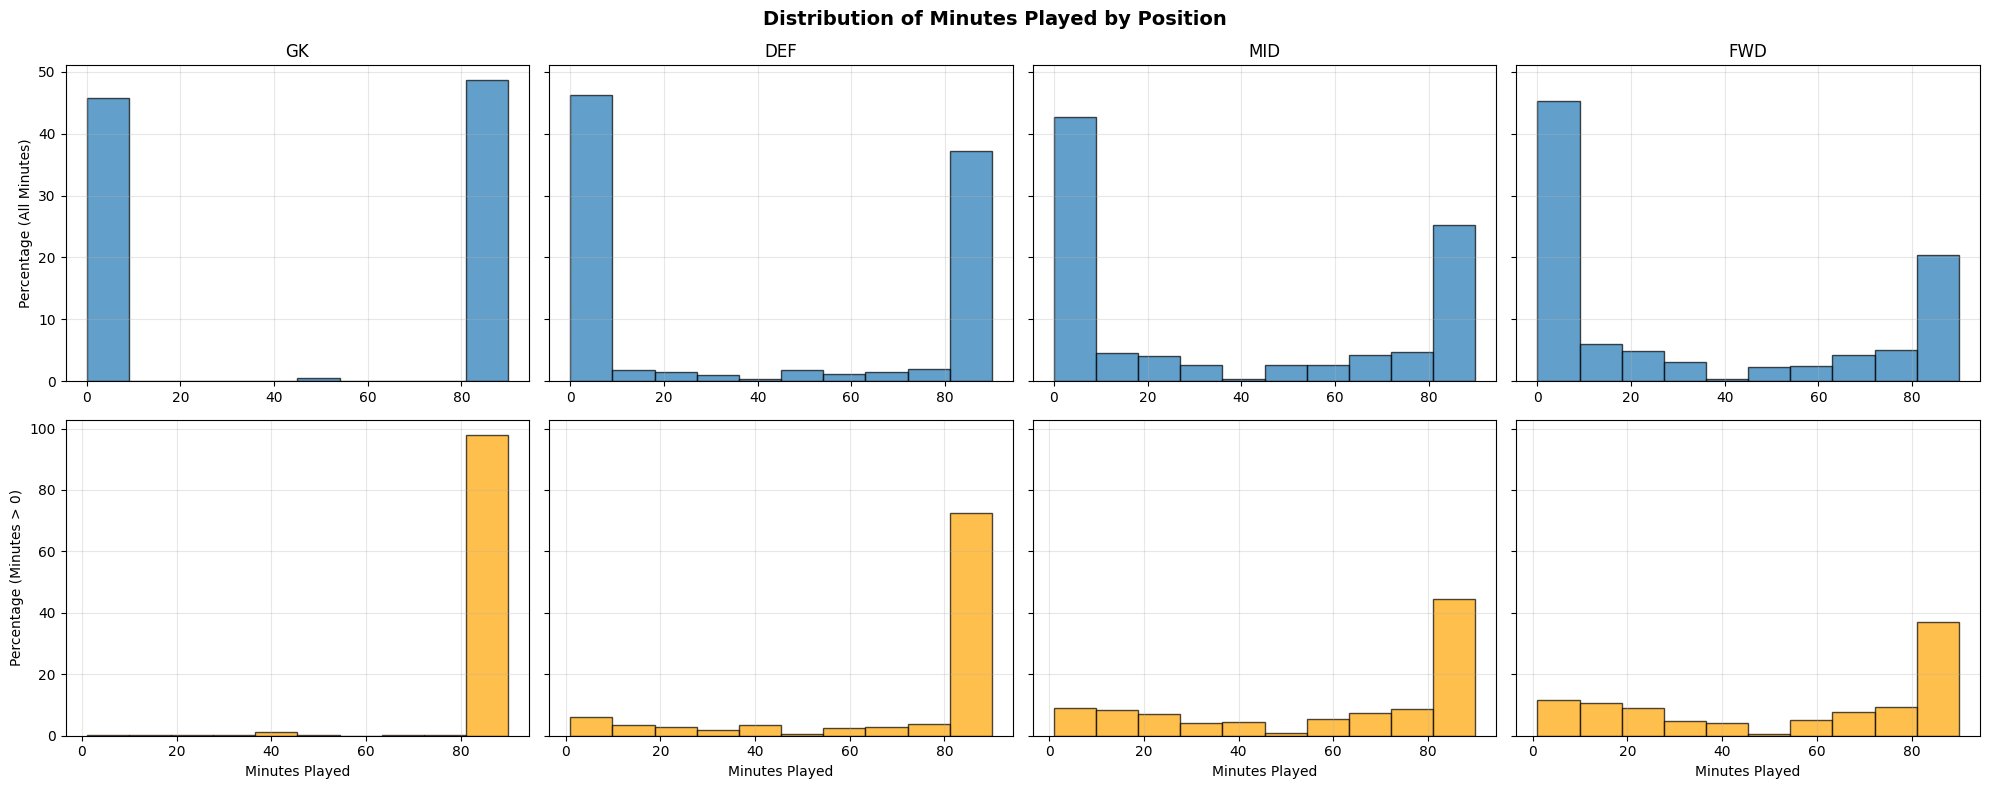

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.354


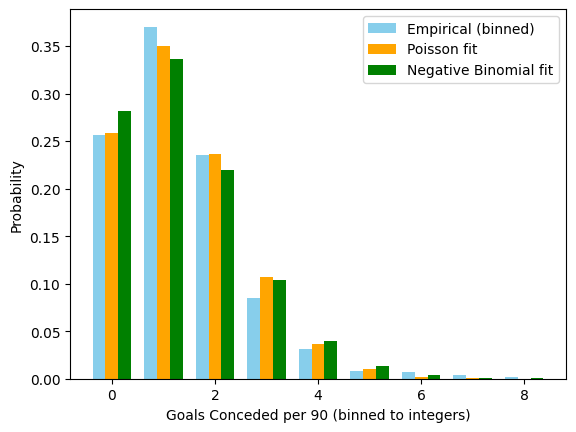

Mean: 1.345, Variance: 1.512
Overdispersion ratio (Var/Mean): 1.124
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.258


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.223


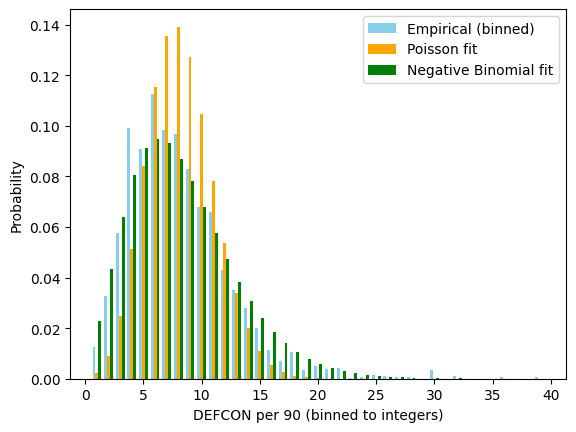

Mean: 8.214, Variance: 21.030
Overdispersion ratio (Var/Mean): 2.560
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [21]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.200


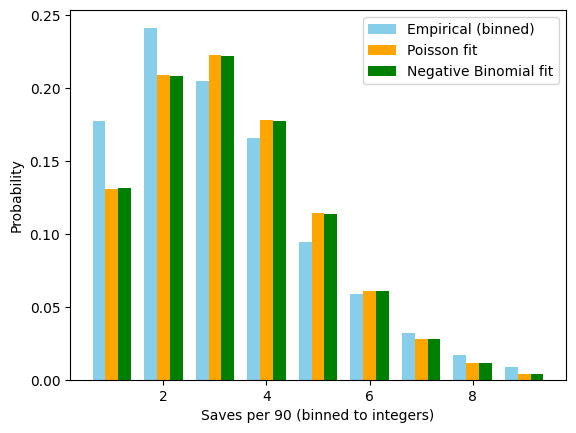

Mean: 3.200, Variance: 3.231
Overdispersion ratio (Var/Mean): 1.010
✅ Poisson assumption looks reasonable.


In [22]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [23]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=current_gw+1)]

In [24]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [25]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_12860\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    6041.000000
mean       60.478099
std        20.469063
min        15.245438
25%        41.762216
50%        61.512409
75%        80.150833
max        89.951693
Name: mins_pred, dtype: float64

In [26]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_12860\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    5663.000000
mean        0.161109
std         0.139693
min         0.028257
25%         0.055439
50%         0.118230
75%         0.218966
max         0.805709
Name: xgp90_pred, dtype: float64

In [27]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_12860\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    5663.000000
mean        0.099656
std         0.064440
min         0.031188
25%         0.050269
50%         0.076253
75%         0.134218
max         0.452062
Name: xap90_pred, dtype: float64

In [28]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_12860\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    6041.000000
mean        1.436771
std         0.352484
min         0.507626
25%         1.183245
50%         1.421625
75%         1.687737
max         2.901055
Name: xgcp90_pred, dtype: float64

In [29]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_12860\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    6041.000000
mean       15.812166
std         3.188341
min         3.550592
25%        13.607257
50%        15.535927
75%        17.786150
max        43.311509
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.448
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                          3.442e+04
Date:                Fri, 20 Feb 2026   Prob (F-statistic):                        0.00
Time:                        10:52:17   Log-Likelihood:                         -39989.
No. Observations:               42438   AIC:                                  7.998e+04
Df Residuals:                   42437   BIC:                                  7.999e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

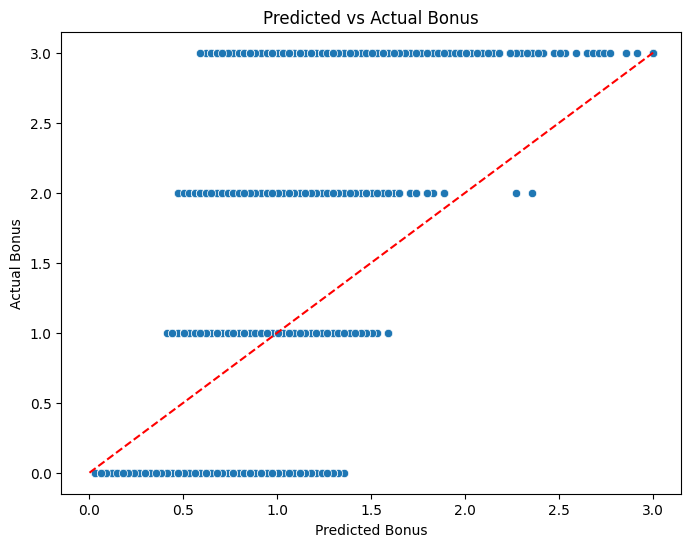

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.458976  0.229352  1.106243  1.946706
FWD           0.332375  0.196741  1.047316  1.707514
GK            0.488692  0.244270  1.115318  2.008262
GKP                NaN       NaN       NaN       NaN
MID           0.396812  0.245045  1.049147  1.824294


C:\Users\Chris\AppData\Local\Temp\ipykernel_12860\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [30]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [31]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_12860\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [32]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_12860\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    378.000000
mean       3.083823
std        0.631006
min        1.217283
25%        2.662317
50%        3.072766
75%        3.501568
max        4.754410
Name: xsavesp90_pred, dtype: float64

In [33]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_12860\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    5663.000000
mean        7.810331
std         1.857180
min         2.338422
25%         6.723273
50%         7.991689
75%         9.088063
max        13.627918
Name: xdefconp90_pred, dtype: float64

In [34]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
129254,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,27.0,West Ham,977.455615,34.799570,0.125667,0.146871,1.758949
129330,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,28.0,Sunderland,1037.474334,34.712903,0.117598,0.164312,1.699735
129333,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,29.0,Brentford,1085.685411,34.712903,0.110608,0.164987,1.803634
129988,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,30.0,Man City,1228.565364,26.027565,0.134047,0.119727,2.199956
129990,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,31.0,Aston Villa,1168.435218,26.547287,0.139858,0.121995,2.101555


In [35]:
prediction_data[
    (prediction_data['event']==current_gw+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
141629,Marc Guiu Paz,252.0,42.0,Chelsea,FWD,20252026.0,27.0,Burnley,890.940966,45.354150,0.805709,0.360762,1.492828
144334,Norberto Bercique Gomes Betuncal,311.0,50.0,Everton,FWD,20252026.0,27.0,Man Utd,1096.195946,34.567923,0.753532,0.169281,2.050115
138300,Jean-Philippe Mateta,283.0,75.0,Crystal Palace,FWD,20252026.0,27.0,Wolves,916.012245,58.790457,0.707938,0.266648,1.371225
144160,Odsonne Édouard,285.0,50.0,Crystal Palace,FWD,20252026.0,27.0,Wolves,916.012245,31.096190,0.692562,0.343976,1.945623
135455,Fábio Freitas Gouveia Carvalho,123.0,47.0,Brentford,MID,20252026.0,27.0,Brighton,1057.578227,42.628984,0.648316,0.255580,1.763842
145420,Rio Ngumoha,686.0,43.0,Liverpool,MID,20252026.0,27.0,Nott'm Forest,1017.056271,29.371797,0.611215,0.256262,1.134937
134305,Eddie Nketiah,284.0,54.0,Crystal Palace,FWD,20252026.0,27.0,Wolves,916.012245,39.761302,0.607311,0.253888,1.439668
130341,Alexander Isak,499.0,103.0,Liverpool,FWD,20252026.0,27.0,Nott'm Forest,1017.056271,39.445349,0.587257,0.317726,1.577006
131650,Benjamin Sesko,681.0,72.0,Man Utd,FWD,20252026.0,27.0,Everton,1061.380748,44.712391,0.582378,0.072081,1.455595
137074,Igor Thiago Nascimento Rodrigues,136.0,70.0,Brentford,FWD,20252026.0,27.0,Brighton,1057.578227,82.123631,0.570411,0.068476,1.356367


In [36]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [37]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [38]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_12860\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_12860\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykerne

In [39]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]

In [40]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6041 entries, 0 to 6040
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          6041 non-null   object 
 1   team_name               6041 non-null   object 
 2   team_elo                6041 non-null   float64
 3   element                 6041 non-null   float64
 4   position                6041 non-null   object 
 5   opp_team_name           6041 non-null   object 
 6   opp_team_elo            6041 non-null   float64
 7   season                  6041 non-null   float64
 8   value                   6041 non-null   float64
 9   event                   6041 non-null   float64
 10  mins_pred               6041 non-null   float64
 11  xgp90_pred              5663 non-null   float64
 12  xap90_pred              5663 non-null   float64
 13  xgcp90_pred             6041 non-null   float64
 14  xpoints_mins            6041 non-null   

In [41]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [42]:
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
""")

In [43]:
print(f"Gameweek {current_gw+1} Predictions")
prediction_data[
    prediction_data['event']==current_gw+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 27 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
139741,Jurriën Timber,8.0,27.0,64.0,Arsenal,DEF,Spurs,981.604056,87.474846,1.939771,0.432037,0.218609,2.360466,0.0,-0.100777,0.540355,0.602440,5.992902
135829,Gabriel dos Santos Magalhães,5.0,27.0,71.0,Arsenal,DEF,Spurs,981.604056,84.931269,1.923659,0.325787,0.361681,2.134297,0.0,-0.135254,0.540355,0.602301,5.752827
148488,William Saliba,6.0,27.0,61.0,Arsenal,DEF,Spurs,981.604056,85.705007,1.928939,0.237625,0.144446,2.249793,0.0,-0.116815,0.540355,0.596866,5.581209
134761,Enzo Fernández,237.0,27.0,69.0,Chelsea,MID,Burnley,890.940966,83.664683,1.914234,0.978944,0.786141,0.412128,0.0,0.000000,0.513022,0.686751,5.291221
131055,Antoine Semenyo,82.0,27.0,79.0,Man City,MID,Newcastle,1083.811172,86.703319,1.935253,1.430496,0.594495,0.259886,0.0,0.000000,0.513022,0.505159,5.238312
133001,Cole Palmer,235.0,27.0,105.0,Chelsea,MID,Burnley,890.940966,67.650299,1.682445,1.183399,0.548359,0.401671,0.0,0.000000,0.513022,0.857754,5.186651
145667,Riccardo Calafiori,7.0,27.0,56.0,Arsenal,DEF,Spurs,981.604056,60.862540,1.521550,0.242650,0.127716,2.205656,0.0,-0.123649,0.540355,0.589897,5.104176
143313,Moisés Caicedo Corozo,241.0,27.0,57.0,Chelsea,MID,Burnley,890.940966,85.775505,1.929403,0.903543,0.654143,0.437250,0.0,0.000000,0.513022,0.630324,5.067684
135510,Florian Wirtz,382.0,27.0,84.0,Liverpool,MID,Nott'm Forest,1017.056271,85.439063,1.927163,1.013434,0.626575,0.381610,0.0,0.000000,0.513022,0.568776,5.030581
133775,Declan Rice,21.0,27.0,75.0,Arsenal,MID,Spurs,981.604056,84.185093,1.918228,0.736695,0.645091,0.488726,0.0,0.000000,0.513022,0.711297,5.013059


In [44]:
print(f"Next 5 GWs: GW{current_gw+1} - GW{current_gw+5}")
next_5_gws_filter = (prediction_data['event']>=current_gw)&(prediction_data['event']<=current_gw+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW27 - GW31


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
86,Conor Bradley,310.892931,7.771224,4.069234,1.664445,7.416176,0.0,-1.438076,2.701777,3.022790,25.207571
151,Florian Wirtz,427.072875,9.634987,5.099814,3.179699,1.872200,0.0,0.000000,2.565111,2.827396,25.179206
188,Igor Thiago Nascimento Rodrigues,408.848447,9.490535,10.689696,0.985192,0.000000,0.0,0.000000,1.301988,2.540295,25.007706
184,Ibrahima Konaté,437.324060,9.698572,1.437434,0.700522,8.634455,0.0,-1.096040,2.701777,2.883457,24.960176
489,Virgil van Dijk,430.079316,9.654818,1.353276,0.684079,8.426880,0.0,-1.149893,2.701777,2.959564,24.630503
65,Bruno Guimarães Rodriguez Moura,422.019959,9.599283,5.492112,2.668252,1.224457,0.0,0.000000,2.565111,2.860347,24.409561
139,Ethan Pinnock,329.795752,8.223492,5.959803,0.679335,5.909952,0.0,-1.917904,2.701777,2.455482,24.011936
355,Mohamed Salah,392.444118,9.319795,5.364810,1.934558,2.034324,0.0,0.000000,2.565111,2.475035,23.693633
359,Morgan Rogers,433.108081,9.673783,4.273951,2.349770,1.847020,0.0,0.000000,2.565111,2.814250,23.523884
142,Ezri Konsa Ngoyo,437.719310,9.700803,1.170628,0.714541,7.781937,0.0,-1.310704,2.701777,2.678543,23.437525


In [45]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
65,Bruno Guimarães Rodriguez Moura,1012.784649,23.037811,13.254743,6.907461,3.091752,0.0,0.000000,6.156265,6.980709,59.428741
188,Igor Thiago Nascimento Rodrigues,982.599418,22.789931,25.454495,2.278800,0.000000,0.0,0.000000,3.124771,5.770163,59.418160
151,Florian Wirtz,1025.146317,23.125129,12.007343,7.164687,3.787513,0.0,0.000000,6.156265,6.744606,58.985543
32,Antoine Semenyo,953.465940,21.286139,15.778326,6.239484,3.452732,0.0,0.000000,5.643243,5.697883,58.097807
263,Jurriën Timber,959.509932,21.320164,4.740944,2.429733,19.611501,0.0,-2.388623,5.943910,5.939123,57.596752
184,Ibrahima Konaté,1049.577743,23.276572,3.438148,1.615768,19.021611,0.0,-3.063360,6.484266,6.432350,57.205356
86,Conor Bradley,744.103360,18.600506,9.858331,3.955278,15.377563,0.0,-4.238831,6.484266,6.838321,56.875434
64,Bruno Borges Fernandes,1028.499310,23.147482,11.475371,5.906739,3.216056,0.0,0.000000,6.156265,6.628988,56.530901
159,Gabriel dos Santos Magalhães,931.090390,21.135732,3.644459,3.458563,18.808695,0.0,-2.534107,5.943910,6.060464,56.517718
359,Morgan Rogers,1039.441866,23.216967,10.276232,5.602634,4.287101,0.0,0.000000,6.156265,6.618010,56.157210


In [46]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': current_gw
})

In [47]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [48]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            pg.fixture, pg.total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    WHERE 1=0;  -- Empty table with correct schema
""")

In [49]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 6041 new predictions to predictions_allgws


In [50]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==current_gw) & (
    view['event']==current_gw+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points']][future_filter].head()

,player_name_id,event,season,total_points
56813,Erling Haaland,27.0,20252026.0,NaN
62860,Erling Haaland,27.0,20252026.0,NaN
68929,Erling Haaland,27.0,20252026.0,NaN


In [51]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=13)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].head(10)

,player_name_id,event,season,total_points,minutes
181636,Erling Haaland,13.0,20252026.0,2.0,90.0
181637,Erling Haaland,14.0,20252026.0,14.0,90.0
181638,Erling Haaland,15.0,20252026.0,2.0,68.0
181639,Erling Haaland,16.0,20252026.0,13.0,90.0
181640,Erling Haaland,17.0,20252026.0,16.0,90.0
181641,Erling Haaland,18.0,20252026.0,2.0,90.0
181642,Erling Haaland,19.0,20252026.0,2.0,90.0
181643,Erling Haaland,20.0,20252026.0,2.0,90.0
181644,Erling Haaland,21.0,20252026.0,6.0,90.0
181645,Erling Haaland,22.0,20252026.0,2.0,79.0


In [52]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
5663,Erling Haaland,2026-01-26 14:27:00.627006,24.0,4.148815,NaN
...,...,...,...,...,...
47468,Erling Haaland,2026-02-09 12:29:03.939012,38.0,4.614883,NaN
40654,Erling Haaland,2026-02-03 14:41:19.430154,38.0,3.970624,NaN
33637,Erling Haaland,2026-02-02 13:38:00.840050,38.0,3.814370,NaN
5672,Erling Haaland,2026-01-26 14:27:00.627006,38.0,3.537848,NaN


In [53]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=current_gw)&(
                df_preds['event']<=current_gw+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2026-01-05 18:33:33.065519 20                  20252026.0 26.0   3.426947
                                                          27.0   3.437517
                                                          28.0   3.421395
                                                          29.0   3.392790
                                                          30.0   3.432445
...                                                                   ...
2026-02-20 10:52:25.776847 26                  20252026.0 27.0   3.414654
                                                          28.0   3.410513
                                                          29.0   3.418767
                                                          30.0   3.443163
                                                          31.0   3.397668

[81 rows x 1 columns]

In [54]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2910
2026-01-07 16:29:20.849190,12
2026-01-08 16:44:49.940956,12
2026-01-22 16:59:38.976316,18
2026-01-25 11:24:25.347489,6
2026-01-26 14:27:00.627006,2970
2026-01-27 11:00:04.422834,2976
2026-02-01 11:57:12.353330,2988
2026-02-02 13:38:00.840050,3006


In [55]:
df_complete.columns.to_list()

['player_name_id',
 'team_name',
 'team_elo',
 'element',
 'position',
 'opp_team_name',
 'opp_team_elo',
 'season',
 'value',
 'event',
 'mins_pred',
 'xgp90_pred',
 'xap90_pred',
 'xgcp90_pred',
 'xpoints_mins',
 'xpoints_goals',
 'xpoints_assists',
 'xpoints_clean_sheets',
 'xpoints_shots_saved',
 'xpoints_goals_conceded',
 'xpoints_defcon',
 'xpoints_bonus',
 'xpoints',
 'in_any_team',
 'in_my_team',
 'prediction_timestamp',
 'prediction_gameweek',
 'total_points',
 'fixture']

In [56]:
filtered = (df_complete['player_name_id'] == 'Bukayo Saka')&(
    df_complete['season']==20252026) & (df_complete['event']==25)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,xpoints,total_points


In [57]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,24,24.000000
mean,2026-01-08 04:37:05.395073024,28.500000
min,2026-01-07 16:29:20.849190,26.000000
25%,2026-01-07 16:29:20.849189888,27.000000
50%,2026-01-08 04:37:05.395073024,28.500000
75%,2026-01-08 16:44:49.940955904,30.000000
max,2026-01-08 16:44:49.940956,31.000000
std,NaN,1.744557


In [58]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{current_gw}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [59]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 34.39 minute(s)


In [60]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)